# 🏏 ICC Men's T20 World Cup 2024 - Comprehensive EDA

## Batting & Bowling Performance Analysis

This notebook provides an extensive exploratory data analysis of the ICC Men's T20 World Cup 2024, covering:
- **Batting Analysis**: Top scorers, averages, strike rates, boundaries, consistency
- **Bowling Analysis**: Wicket-takers, economy rates, dot balls, phase-wise analysis
- **Combined Insights**: Team comparisons, venue impact, match patterns

---

## 1. Import Required Libraries and Load Data

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Load the datasets
deliveries = pd.read_csv('deliveries.csv')
matches = pd.read_csv('matches.csv')

print("Deliveries Dataset Shape:", deliveries.shape)
print("Matches Dataset Shape:", matches.shape)
print("\n" + "="*50)
print("Deliveries Columns:", deliveries.columns.tolist())
print("\n" + "="*50)
print("Matches Columns:", matches.columns.tolist())

Deliveries Dataset Shape: (11472, 22)
Matches Dataset Shape: (52, 18)

Deliveries Columns: ['match_id', 'season', 'start_date', 'venue', 'innings', 'ball', 'batting_team', 'bowling_team', 'striker', 'non_striker', 'bowler', 'runs_off_bat', 'extras', 'wides', 'noballs', 'byes', 'legbyes', 'penalty', 'wicket_type', 'player_dismissed', 'other_wicket_type', 'other_player_dismissed']

Matches Columns: ['season', 'team1', 'team2', 'date', 'match_number', 'venue', 'city', 'toss_winner', 'toss_decision', 'player_of_match', 'umpire1', 'umpire2', 'reserve_umpire', 'match_referee', 'winner', 'winner_runs', 'winner_wickets', 'match_type']


In [2]:
# Display first few rows of each dataset
print("DELIVERIES DATASET:")
display(deliveries.head(10))
print("\n" + "="*80)
print("\nMATCHES DATASET:")
display(matches.head(10))

DELIVERIES DATASET:


,match_id,season,start_date,venue,innings,ball,batting_team,bowling_team,striker,non_striker,...,extras,wides,noballs,byes,legbyes,penalty,wicket_type,player_dismissed,other_wicket_type,other_player_dismissed
0,1,2024,2024-06-02,"Providence Stadium, Guyana",1,0.1,Papua New Guinea,West Indies,TP Ura,A Vala,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2024,2024-06-02,"Providence Stadium, Guyana",1,0.2,Papua New Guinea,West Indies,TP Ura,A Vala,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,2024,2024-06-02,"Providence Stadium, Guyana",1,0.3,Papua New Guinea,West Indies,A Vala,TP Ura,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,2024,2024-06-02,"Providence Stadium, Guyana",1,0.4,Papua New Guinea,West Indies,A Vala,TP Ura,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,2024,2024-06-02,"Providence Stadium, Guyana",1,0.5,Papua New Guinea,West Indies,A Vala,TP Ura,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1,2024,2024-06-02,"Providence Stadium, Guyana",1,0.6,Papua New Guinea,West Indies,A Vala,TP Ura,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,1,2024,2024-06-02,"Providence Stadium, Guyana",1,1.1,Papua New Guinea,West Indies,TP Ura,A Vala,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,1,2024,2024-06-02,"Providence Stadium, Guyana",1,1.2,Papua New Guinea,West Indies,A Vala,TP Ura,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,1,2024,2024-06-02,"Providence Stadium, Guyana",1,1.3,Papua New Guinea,West Indies,A Vala,TP Ura,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,1,2024,2024-06-02,"Providence Stadium, Guyana",1,1.4,Papua New Guinea,West Indies,TP Ura,A Vala,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN




MATCHES DATASET:


,season,team1,team2,date,match_number,venue,city,toss_winner,toss_decision,player_of_match,umpire1,umpire2,reserve_umpire,match_referee,winner,winner_runs,winner_wickets,match_type
0,2024,Canada,United States of America,2024/06/01,1,Grand Prairie Stadium,Dallas,United States of America,field,Aaron Jones,RK Illingworth,Sharfuddoula,L Rusere,RB Richardson,United States of America,NaN,7.0,Group
1,2024,Papua New Guinea,West Indies,2024/06/02,2,Providence Stadium,Providence,West Indies,field,RL Chase,AT Holdstock,Rashid Riaz,HDPK Dharmasena,AJ Pycroft,West Indies,NaN,5.0,Group
2,2024,Oman,Namibia,2024/06/02,3,Kensington Oval,Bridgetown,Namibia,field,D Wiese,J Madanagopal,JS Wilson,Asif Yaqoob,RS Madugalle,NaN,NaN,NaN,Group
3,2024,Sri Lanka,South Africa,2024/06/03,4,Nassau County International Cricket Stadium,New York,Sri Lanka,bat,A Nortje,CM Brown,RA Kettleborough,AG Wharf,JJ Crowe,South Africa,NaN,6.0,Group
4,2024,Afghanistan,Uganda,2024/06/03,5,Providence Stadium,Providence,Uganda,field,Fazalhaq Farooqi,Ahsan Raza,HDPK Dharmasena,Rashid Riaz,AJ Pycroft,Afghanistan,125.0,NaN,Group
5,2024,Scotland,England,2024/06/04,6,Kensington Oval,Bridgetown,Scotland,bat,NaN,Asif Yaqoob,Nitin Menon,J Madanagopal,RS Madugalle,No Result,NaN,NaN,Group
6,2024,Nepal,Netherlands,2024/06/04,7,Grand Prairie Stadium,Dallas,Netherlands,field,TJG Pringle,L Rusere,RJ Tucker,RK Illingworth,RB Richardson,Netherlands,NaN,6.0,Group
7,2024,Ireland,India,2024/06/05,8,Nassau County International Cricket Stadium,New York,India,field,JJ Bumrah,AG Wharf,CB Gaffaney,CM Brown,DC Boon,India,NaN,8.0,Group
8,2024,Papua New Guinea,Uganda,2024/06/05,9,Providence Stadium,Providence,Uganda,field,Riazat Ali Shah,AT Holdstock,Rashid Riaz,HDPK Dharmasena,J Srinath,Uganda,NaN,3.0,Group
9,2024,Australia,Oman,2024/06/05,10,Kensington Oval,Bridgetown,Oman,field,MP Stoinis,Asif Yaqoob,JS Wilson,Nitin Menon,RS Madugalle,Australia,39.0,NaN,Group


## 2. Data Cleaning and Preprocessing

In [3]:
# Check for missing values
print("Missing values in Deliveries:")
print(deliveries.isnull().sum())
print("\n" + "="*50)
print("\nMissing values in Matches:")
print(matches.isnull().sum())

Missing values in Deliveries:
match_id                      0
season                        0
start_date                    0
venue                         0
innings                       0
ball                          0
batting_team                  0
bowling_team                  0
striker                       0
non_striker                   0
bowler                        0
runs_off_bat                  0
extras                        0
wides                     11064
noballs                   11427
byes                      11431
legbyes                   11293
penalty                   11471
wicket_type               10788
player_dismissed          10788
other_wicket_type         11472
other_player_dismissed    11472
dtype: int64


Missing values in Matches:
season              0
team1               0
team2               0
date                0
match_number        0
venue               0
city                0
toss_winner         0
toss_decision       0
player_of_match     1
umpi

In [4]:
# Data preprocessing and feature engineering
# Convert date columns to datetime
matches['date'] = pd.to_datetime(matches['date'])
deliveries['start_date'] = pd.to_datetime(deliveries['start_date'])

# Fill missing numeric values with 0
numeric_cols = ['wides', 'noballs', 'byes', 'legbyes', 'penalty']
deliveries[numeric_cols] = deliveries[numeric_cols].fillna(0)

# Calculate total runs per delivery
deliveries['total_runs'] = deliveries['runs_off_bat'] + deliveries['extras']

# Extract over number from ball column
deliveries['over'] = deliveries['ball'].apply(lambda x: int(x))

# Categorize phases
def get_phase(over):
    if over < 6:
        return 'Powerplay (1-6)'
    elif over < 16:
        return 'Middle (7-16)'
    else:
        return 'Death (17-20)'

deliveries['phase'] = deliveries['over'].apply(get_phase)

# Check if it's a legal delivery
deliveries['is_legal'] = (deliveries['wides'] == 0) & (deliveries['noballs'] == 0)

# Check for boundaries
deliveries['is_four'] = deliveries['runs_off_bat'] == 4
deliveries['is_six'] = deliveries['runs_off_bat'] == 6
deliveries['is_boundary'] = deliveries['is_four'] | deliveries['is_six']

# Check for dot balls
deliveries['is_dot'] = (deliveries['runs_off_bat'] == 0) & (deliveries['extras'] == 0)

# Create match identifier by combining teams and date for merging
print("Data preprocessing completed!")
print(f"Total deliveries: {len(deliveries)}")
print(f"Total matches: {len(matches)}")

Data preprocessing completed!
Total deliveries: 11472
Total matches: 52


In [5]:
# Create aggregated batting statistics for each player
batting_stats = deliveries.groupby('striker').agg({
    'runs_off_bat': 'sum',
    'ball': 'count',
    'is_four': 'sum',
    'is_six': 'sum',
    'match_id': 'nunique'
}).reset_index()

batting_stats.columns = ['player', 'total_runs', 'balls_faced', 'fours', 'sixes', 'innings']

# Calculate dismissals for each player
dismissals = deliveries[deliveries['player_dismissed'].notna()].groupby('player_dismissed').size().reset_index(name='dismissals')
batting_stats = batting_stats.merge(dismissals, left_on='player', right_on='player_dismissed', how='left')
batting_stats['dismissals'] = batting_stats['dismissals'].fillna(0).astype(int)
batting_stats = batting_stats.drop('player_dismissed', axis=1, errors='ignore')

# Calculate derived metrics
batting_stats['strike_rate'] = (batting_stats['total_runs'] / batting_stats['balls_faced'] * 100).round(2)
batting_stats['batting_average'] = (batting_stats['total_runs'] / batting_stats['dismissals'].replace(0, np.nan)).round(2)
batting_stats['boundary_runs'] = batting_stats['fours'] * 4 + batting_stats['sixes'] * 6
batting_stats['boundary_pct'] = (batting_stats['boundary_runs'] / batting_stats['total_runs'] * 100).round(2)

print("Batting Statistics Summary:")
display(batting_stats.sort_values('total_runs', ascending=False).head(15))

Batting Statistics Summary:


,player,total_runs,balls_faced,fours,sixes,innings,dismissals,strike_rate,batting_average,boundary_runs,boundary_pct
195,Rahmanullah Gurbaz,281,233,18,16,8,8,120.60,35.12,168,59.79
188,RG Sharma,257,169,24,15,8,8,152.07,32.12,186,72.37
232,TM Head,255,165,26,15,7,6,154.55,42.50,194,76.08
178,Q de Kock,243,180,21,13,8,9,135.00,27.00,162,66.67
81,Ibrahim Zadran,231,221,25,4,8,8,104.52,28.88,124,53.68
155,N Pooran,228,163,15,17,7,6,139.88,38.00,162,71.05
11,AGS Gous,219,153,20,11,6,5,143.14,43.80,146,66.67
89,JC Buttler,214,140,22,10,7,5,152.86,42.80,148,69.16
209,SA Yadav,199,148,15,10,8,7,134.46,28.43,120,60.30
72,H Klaasen,190,157,9,13,8,6,121.02,31.67,114,60.00


In [6]:
# Create aggregated bowling statistics for each bowler
bowling_stats = deliveries.groupby('bowler').agg({
    'total_runs': 'sum',
    'ball': 'count',
    'is_dot': 'sum',
    'is_four': 'sum',
    'is_six': 'sum',
    'wides': lambda x: (x > 0).sum(),
    'noballs': lambda x: (x > 0).sum(),
    'match_id': 'nunique'
}).reset_index()

bowling_stats.columns = ['bowler', 'runs_conceded', 'balls_bowled', 'dot_balls', 'fours_conceded', 
                         'sixes_conceded', 'wides', 'noballs', 'matches']

# Calculate wickets for each bowler
wickets = deliveries[deliveries['wicket_type'].notna()].groupby('bowler').size().reset_index(name='wickets')
bowling_stats = bowling_stats.merge(wickets, on='bowler', how='left')
bowling_stats['wickets'] = bowling_stats['wickets'].fillna(0).astype(int)

# Calculate legal deliveries
bowling_stats['legal_balls'] = bowling_stats['balls_bowled'] - bowling_stats['wides'] - bowling_stats['noballs']

# Calculate derived metrics
bowling_stats['overs'] = (bowling_stats['legal_balls'] // 6) + (bowling_stats['legal_balls'] % 6) / 10
bowling_stats['economy_rate'] = (bowling_stats['runs_conceded'] / (bowling_stats['legal_balls'] / 6)).round(2)
bowling_stats['bowling_average'] = (bowling_stats['runs_conceded'] / bowling_stats['wickets'].replace(0, np.nan)).round(2)
bowling_stats['bowling_sr'] = (bowling_stats['legal_balls'] / bowling_stats['wickets'].replace(0, np.nan)).round(2)
bowling_stats['dot_ball_pct'] = (bowling_stats['dot_balls'] / bowling_stats['legal_balls'] * 100).round(2)

print("Bowling Statistics Summary:")
display(bowling_stats.sort_values('wickets', ascending=False).head(15))

Bowling Statistics Summary:


,bowler,runs_conceded,balls_bowled,dot_balls,fours_conceded,sixes_conceded,wides,noballs,matches,wickets,legal_balls,overs,economy_rate,bowling_average,bowling_sr,dot_ball_pct
18,Arshdeep Singh,223,196,90,23,6,15,1,8,18,180,30.0,7.43,12.39,10.00,50.00
48,Fazalhaq Farooqi,176,164,79,18,2,10,2,8,17,152,25.2,6.95,10.35,8.94,51.97
117,Naveen-ul-Haq,165,168,85,15,5,8,0,8,16,160,26.4,6.19,10.31,10.00,53.12
3,A Nortje,209,224,104,13,7,12,2,9,16,210,35.0,5.97,13.06,13.12,49.52
67,JJ Bumrah,138,179,102,10,2,1,0,8,15,178,29.4,4.65,9.20,11.87,57.30
74,K Rabada,200,194,91,18,7,7,1,9,15,186,31.0,6.45,13.33,12.40,48.92
13,AS Joseph,179,154,63,15,5,5,2,7,14,147,24.3,7.31,12.79,10.50,42.86
134,Rishad Hossain,196,154,67,13,10,4,0,7,14,150,25.0,7.84,14.00,10.71,44.67
132,Rashid Khan,188,181,76,14,5,7,0,8,14,174,29.0,6.48,13.43,12.43,43.68
5,A Zampa,192,169,64,7,11,1,0,7,13,168,28.0,6.86,14.77,12.92,38.10


---
# 🏏 PART 1: BATTING PERFORMANCE ANALYSIS
---

## 3. Top Run Scorers in the Tournament

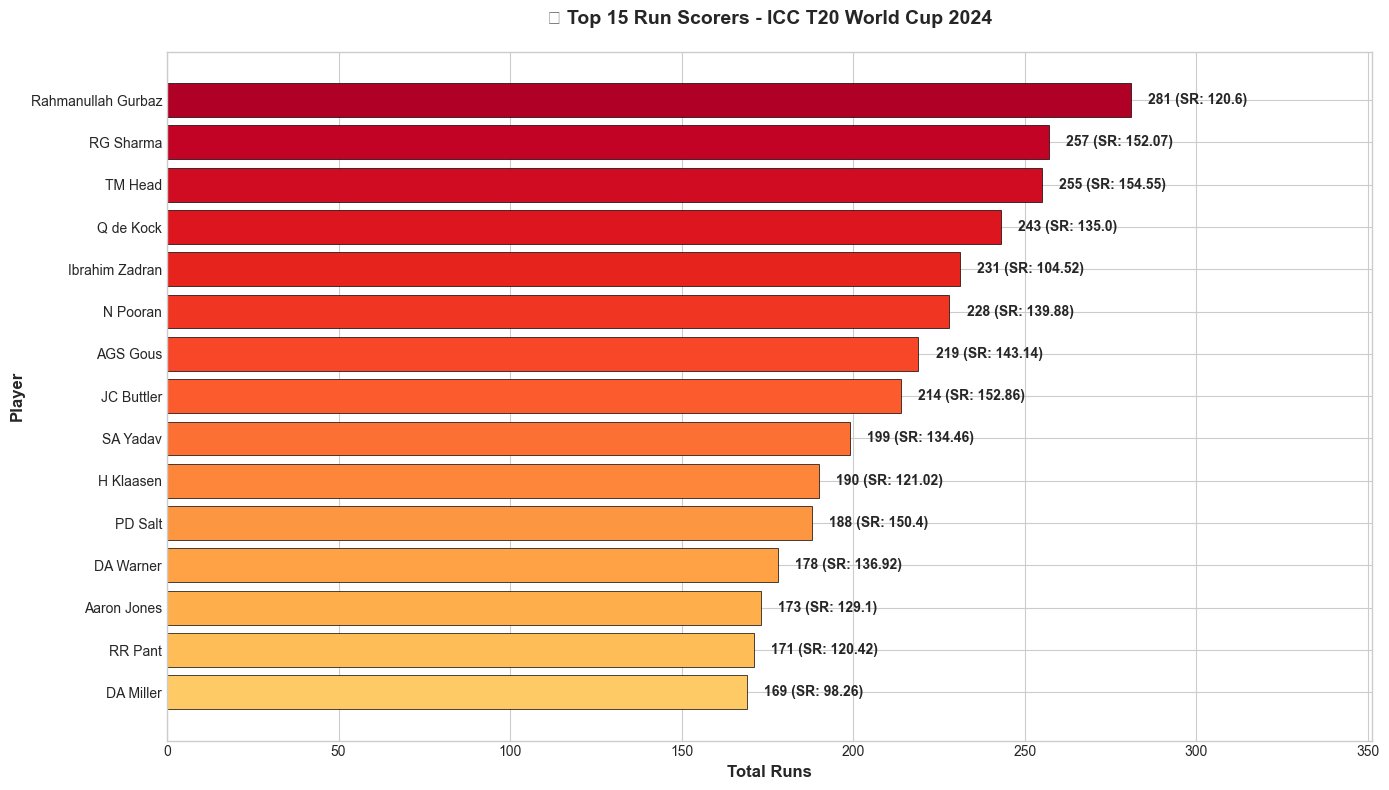


📊 Top 15 Run Scorers Summary:


,player,total_runs,innings,balls_faced,strike_rate,fours,sixes
195,Rahmanullah Gurbaz,281,8,233,120.60,18,16
188,RG Sharma,257,8,169,152.07,24,15
232,TM Head,255,7,165,154.55,26,15
178,Q de Kock,243,8,180,135.00,21,13
81,Ibrahim Zadran,231,8,221,104.52,25,4
155,N Pooran,228,7,163,139.88,15,17
11,AGS Gous,219,6,153,143.14,20,11
89,JC Buttler,214,7,140,152.86,22,10
209,SA Yadav,199,8,148,134.46,15,10
72,H Klaasen,190,8,157,121.02,9,13


In [7]:
# Top 15 Run Scorers
top_scorers = batting_stats.nlargest(15, 'total_runs')

fig, ax = plt.subplots(figsize=(14, 8))
colors = plt.cm.YlOrRd(np.linspace(0.3, 0.9, 15))[::-1]
bars = ax.barh(top_scorers['player'], top_scorers['total_runs'], color=colors, edgecolor='black', linewidth=0.5)

# Add value labels
for bar, runs, sr in zip(bars, top_scorers['total_runs'], top_scorers['strike_rate']):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2, 
            f'{int(runs)} (SR: {sr})', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Total Runs', fontsize=12, fontweight='bold')
ax.set_ylabel('Player', fontsize=12, fontweight='bold')
ax.set_title('🏏 Top 15 Run Scorers - ICC T20 World Cup 2024', fontsize=14, fontweight='bold', pad=20)
ax.invert_yaxis()
ax.set_xlim(0, max(top_scorers['total_runs']) * 1.25)
plt.tight_layout()
plt.show()

print("\n📊 Top 15 Run Scorers Summary:")
display(top_scorers[['player', 'total_runs', 'innings', 'balls_faced', 'strike_rate', 'fours', 'sixes']])

## 4. Batting Average Distribution Across Players

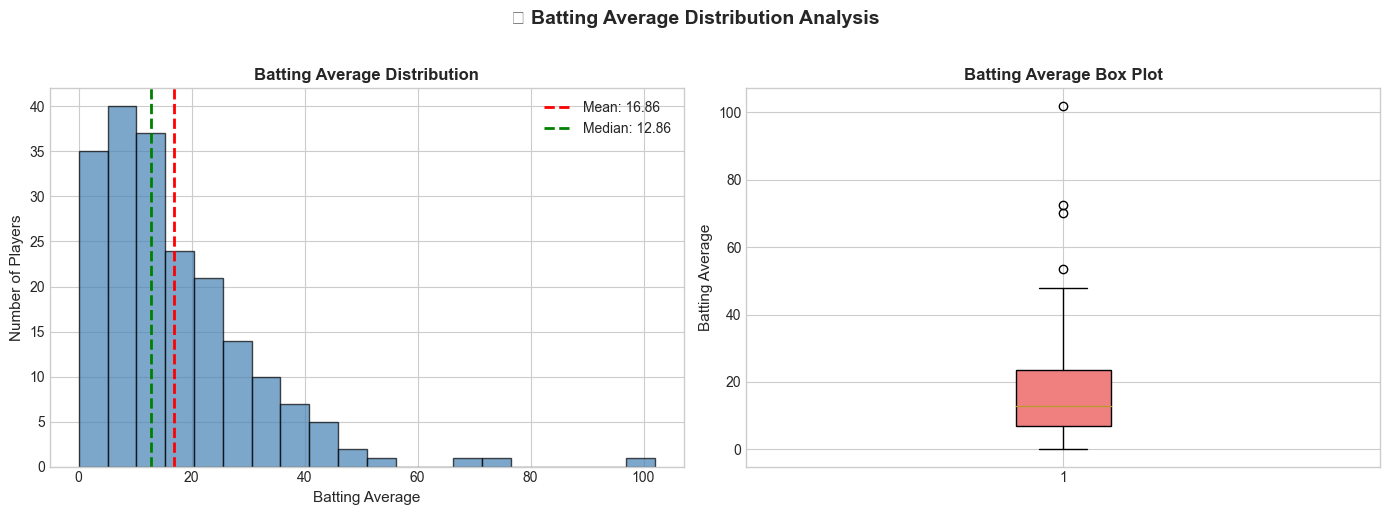


📈 Batting Average Statistics:
   Mean: 16.86
   Median: 12.86
   Std Dev: 14.17
   Max: 102.00 (RD Berrington)


In [8]:
# Filter for players with at least 2 innings and 1 dismissal for meaningful average
qualified_batsmen = batting_stats[(batting_stats['innings'] >= 2) & (batting_stats['dismissals'] >= 1)].copy()
qualified_batsmen = qualified_batsmen[qualified_batsmen['batting_average'].notna()]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(qualified_batsmen['batting_average'], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(qualified_batsmen['batting_average'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {qualified_batsmen['batting_average'].mean():.2f}")
axes[0].axvline(qualified_batsmen['batting_average'].median(), color='green', linestyle='--', linewidth=2, label=f"Median: {qualified_batsmen['batting_average'].median():.2f}")
axes[0].set_xlabel('Batting Average', fontsize=11)
axes[0].set_ylabel('Number of Players', fontsize=11)
axes[0].set_title('Batting Average Distribution', fontsize=12, fontweight='bold')
axes[0].legend()

# Box Plot
box_data = axes[1].boxplot(qualified_batsmen['batting_average'], vert=True, patch_artist=True)
box_data['boxes'][0].set_facecolor('lightcoral')
axes[1].set_ylabel('Batting Average', fontsize=11)
axes[1].set_title('Batting Average Box Plot', fontsize=12, fontweight='bold')

plt.suptitle('📊 Batting Average Distribution Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\n📈 Batting Average Statistics:")
print(f"   Mean: {qualified_batsmen['batting_average'].mean():.2f}")
print(f"   Median: {qualified_batsmen['batting_average'].median():.2f}")
print(f"   Std Dev: {qualified_batsmen['batting_average'].std():.2f}")
print(f"   Max: {qualified_batsmen['batting_average'].max():.2f} ({qualified_batsmen.loc[qualified_batsmen['batting_average'].idxmax(), 'player']})")

## 5. Strike Rate Distribution of Batsmen

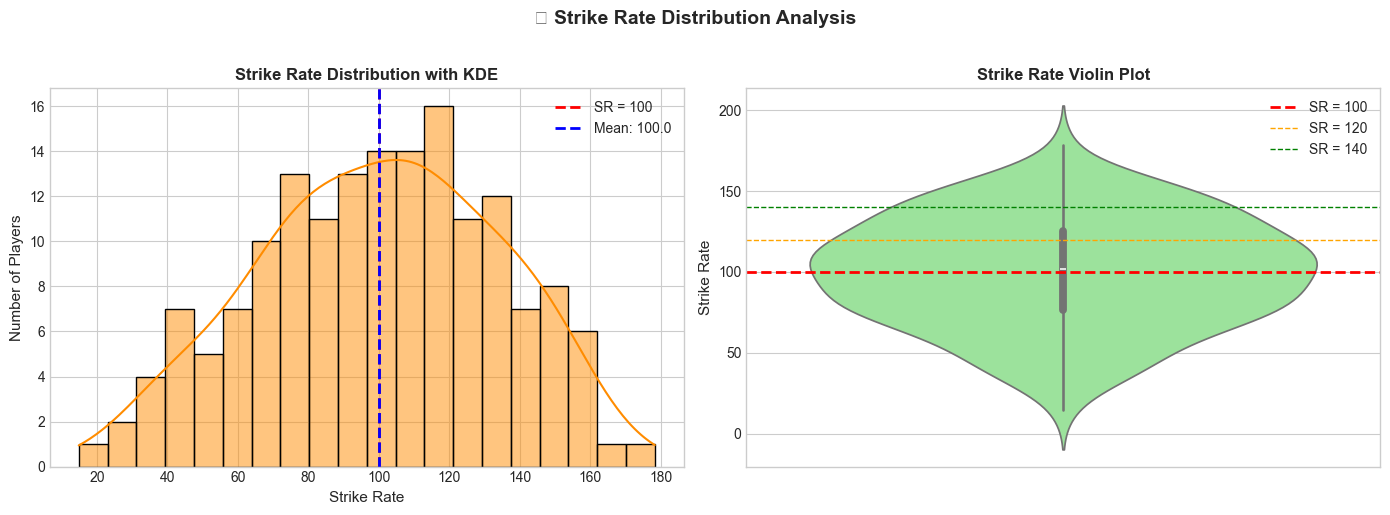


📊 Strike Rate Categories:
sr_category
Below Par (<100)        81
Average (100-120)       33
Good (120-140)          27
Aggressive (140-200)    22
Explosive (200+)         0
Name: count, dtype: int64


In [9]:
# Strike Rate Distribution for qualified batsmen (min 20 balls faced)
sr_qualified = batting_stats[batting_stats['balls_faced'] >= 20].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with KDE
sns.histplot(sr_qualified['strike_rate'], kde=True, color='darkorange', ax=axes[0], bins=20)
axes[0].axvline(100, color='red', linestyle='--', linewidth=2, label='SR = 100')
axes[0].axvline(sr_qualified['strike_rate'].mean(), color='blue', linestyle='--', linewidth=2, 
                label=f"Mean: {sr_qualified['strike_rate'].mean():.1f}")
axes[0].set_xlabel('Strike Rate', fontsize=11)
axes[0].set_ylabel('Number of Players', fontsize=11)
axes[0].set_title('Strike Rate Distribution with KDE', fontsize=12, fontweight='bold')
axes[0].legend()

# Violin Plot
sns.violinplot(y=sr_qualified['strike_rate'], ax=axes[1], color='lightgreen')
axes[1].axhline(100, color='red', linestyle='--', linewidth=2, label='SR = 100')
axes[1].axhline(120, color='orange', linestyle='--', linewidth=1, label='SR = 120')
axes[1].axhline(140, color='green', linestyle='--', linewidth=1, label='SR = 140')
axes[1].set_ylabel('Strike Rate', fontsize=11)
axes[1].set_title('Strike Rate Violin Plot', fontsize=12, fontweight='bold')
axes[1].legend()

plt.suptitle('⚡ Strike Rate Distribution Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Categorize batsmen by strike rate
sr_qualified['sr_category'] = pd.cut(sr_qualified['strike_rate'], 
                                      bins=[0, 100, 120, 140, 200, 300],
                                      labels=['Below Par (<100)', 'Average (100-120)', 
                                             'Good (120-140)', 'Aggressive (140-200)', 'Explosive (200+)'])
print("\n📊 Strike Rate Categories:")
print(sr_qualified['sr_category'].value_counts().sort_index())

## 6. Highest Individual Scores Analysis

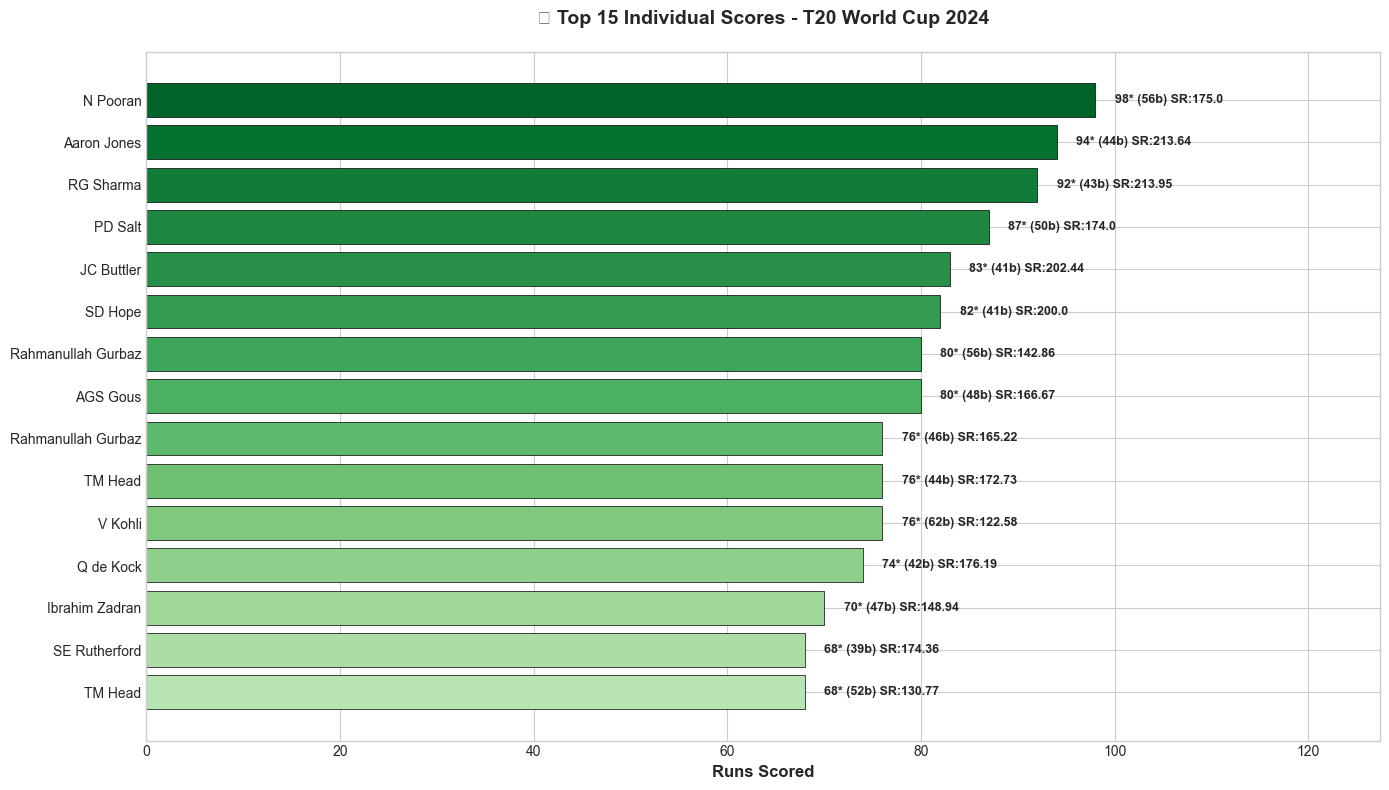


📊 Top 15 Individual Innings:


,player,team,opponent,runs,balls,strike_rate,fours,sixes
597,N Pooran,West Indies,Afghanistan,98,56,175.00,6,8
8,Aaron Jones,United States of America,Canada,94,44,213.64,4,10
770,RG Sharma,India,Australia,92,43,213.95,7,8
636,PD Salt,England,West Indies,87,50,174.00,7,5
747,JC Buttler,England,United States of America,83,41,202.44,6,7
700,SD Hope,West Indies,United States of America,82,41,200.00,4,8
217,Rahmanullah Gurbaz,Afghanistan,New Zealand,80,56,142.86,5,5
618,AGS Gous,United States of America,South Africa,80,48,166.67,5,5
74,Rahmanullah Gurbaz,Afghanistan,Uganda,76,46,165.22,4,4
783,TM Head,Australia,India,76,44,172.73,9,4


In [10]:
# Calculate individual innings scores
innings_scores = deliveries.groupby(['match_id', 'innings', 'striker', 'batting_team', 'bowling_team']).agg({
    'runs_off_bat': 'sum',
    'ball': 'count',
    'is_four': 'sum',
    'is_six': 'sum'
}).reset_index()

innings_scores.columns = ['match_id', 'innings', 'player', 'team', 'opponent', 'runs', 'balls', 'fours', 'sixes']
innings_scores['strike_rate'] = (innings_scores['runs'] / innings_scores['balls'] * 100).round(2)

# Get top 15 individual scores
top_innings = innings_scores.nlargest(15, 'runs')

# Create visualization
fig, ax = plt.subplots(figsize=(14, 8))
colors = plt.cm.Greens(np.linspace(0.3, 0.9, 15))[::-1]

bars = ax.barh(range(len(top_innings)), top_innings['runs'], color=colors, edgecolor='black', linewidth=0.5)

# Add labels
for i, (_, row) in enumerate(top_innings.iterrows()):
    label = f"{row['player']} ({row['team']}) vs {row['opponent']}"
    ax.text(row['runs'] + 2, i, f"{row['runs']}* ({row['balls']}b) SR:{row['strike_rate']}", 
            va='center', fontsize=9, fontweight='bold')

ax.set_yticks(range(len(top_innings)))
ax.set_yticklabels([f"{row['player']}" for _, row in top_innings.iterrows()])
ax.set_xlabel('Runs Scored', fontsize=12, fontweight='bold')
ax.set_title('🏆 Top 15 Individual Scores - T20 World Cup 2024', fontsize=14, fontweight='bold', pad=20)
ax.invert_yaxis()
ax.set_xlim(0, max(top_innings['runs']) * 1.3)
plt.tight_layout()
plt.show()

print("\n📊 Top 15 Individual Innings:")
display(top_innings[['player', 'team', 'opponent', 'runs', 'balls', 'strike_rate', 'fours', 'sixes']])

---
## 🎯 Scoring Pattern & Power Hitting Analysis

## 7. Total Fours and Sixes Hit by Each Batsman

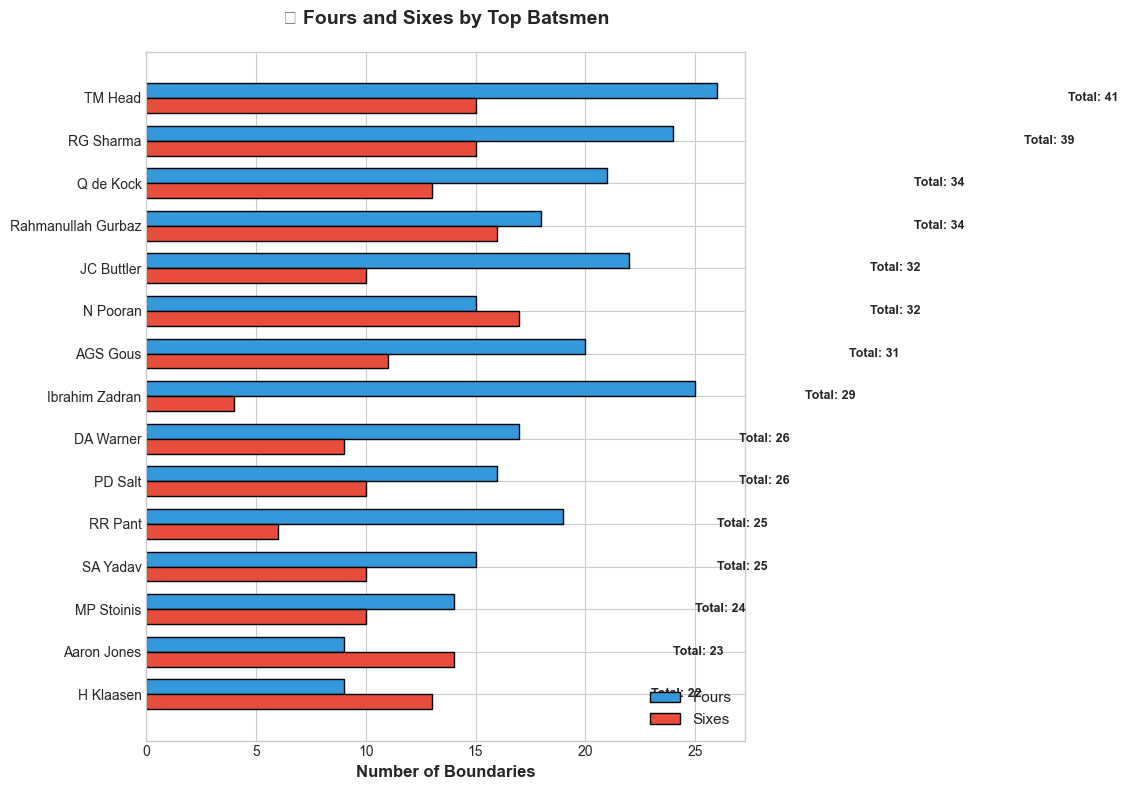


📊 Boundary Kings Summary:


,player,fours,sixes,total_boundaries,boundary_runs,total_runs
232,TM Head,26,15,41,194,255
188,RG Sharma,24,15,39,186,257
178,Q de Kock,21,13,34,162,243
195,Rahmanullah Gurbaz,18,16,34,168,281
89,JC Buttler,22,10,32,148,214
155,N Pooran,15,17,32,162,228
11,AGS Gous,20,11,31,146,219
81,Ibrahim Zadran,25,4,29,124,231
51,DA Warner,17,9,26,122,178
171,PD Salt,16,10,26,124,188


In [11]:
# Top batsmen by total boundaries
boundary_leaders = batting_stats.copy()
boundary_leaders['total_boundaries'] = boundary_leaders['fours'] + boundary_leaders['sixes']
boundary_leaders = boundary_leaders.nlargest(15, 'total_boundaries')

fig, ax = plt.subplots(figsize=(14, 8))

x = np.arange(len(boundary_leaders))
width = 0.35

bars1 = ax.barh(x - width/2, boundary_leaders['fours'], width, label='Fours', color='#3498db', edgecolor='black')
bars2 = ax.barh(x + width/2, boundary_leaders['sixes'], width, label='Sixes', color='#e74c3c', edgecolor='black')

ax.set_yticks(x)
ax.set_yticklabels(boundary_leaders['player'])
ax.legend(loc='lower right', fontsize=11)
ax.set_xlabel('Number of Boundaries', fontsize=12, fontweight='bold')
ax.set_title('🎯 Fours and Sixes by Top Batsmen', fontsize=14, fontweight='bold', pad=20)
ax.invert_yaxis()

# Add total boundary count at the end
for i, (fours, sixes) in enumerate(zip(boundary_leaders['fours'], boundary_leaders['sixes'])):
    ax.text(fours + sixes + 1, i, f'Total: {fours + sixes}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📊 Boundary Kings Summary:")
display(boundary_leaders[['player', 'fours', 'sixes', 'total_boundaries', 'boundary_runs', 'total_runs']])

## 8. Boundary Contribution Percentage to Total Runs

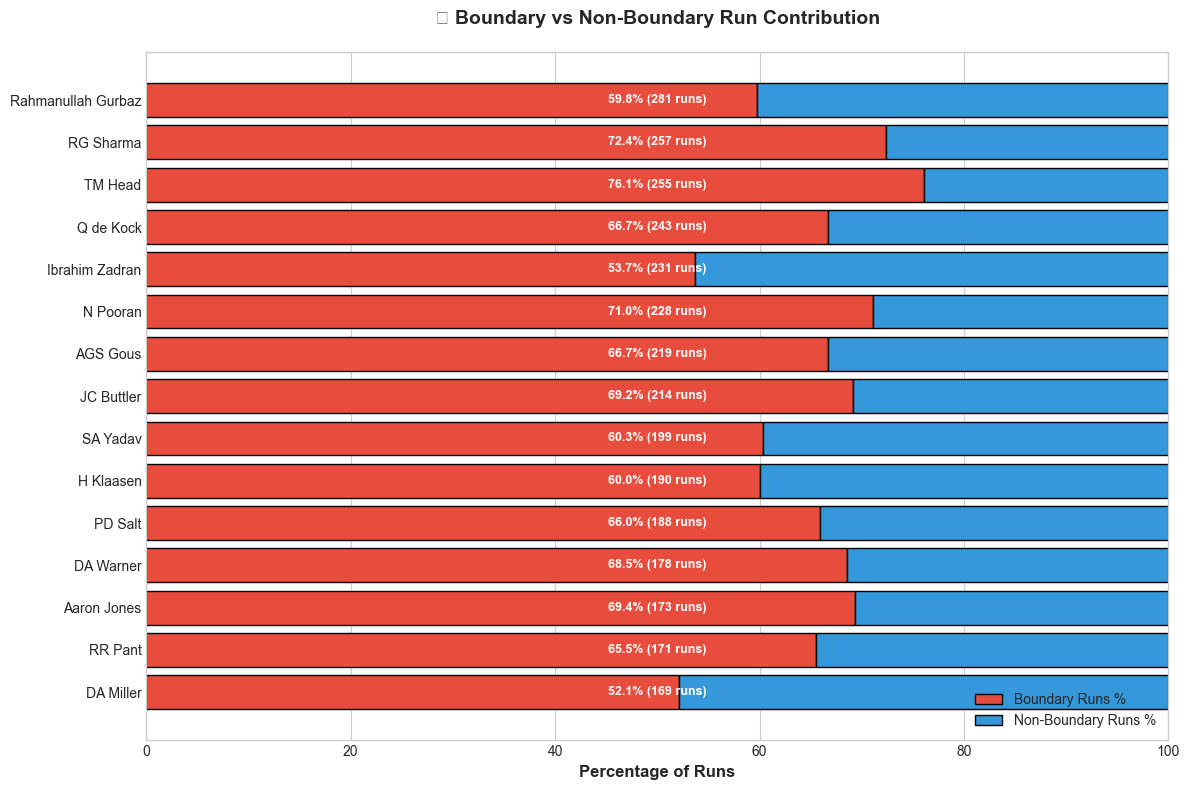


📊 Boundary Dependency Classification:
dependency_level
High (60-70%)       8
Medium (50-60%)     4
Very High (>70%)    3
Low (<50%)          0
Name: count, dtype: int64


In [12]:
# Boundary dependency analysis for top run scorers
boundary_dep = batting_stats[batting_stats['total_runs'] >= 50].copy()
boundary_dep['non_boundary_runs'] = boundary_dep['total_runs'] - boundary_dep['boundary_runs']
boundary_dep['non_boundary_pct'] = 100 - boundary_dep['boundary_pct']
boundary_dep = boundary_dep.nlargest(15, 'total_runs')

fig, ax = plt.subplots(figsize=(12, 8))

# Stacked bar chart
ax.barh(boundary_dep['player'], boundary_dep['boundary_pct'], label='Boundary Runs %', color='#e74c3c', edgecolor='black')
ax.barh(boundary_dep['player'], boundary_dep['non_boundary_pct'], left=boundary_dep['boundary_pct'], 
        label='Non-Boundary Runs %', color='#3498db', edgecolor='black')

ax.set_xlabel('Percentage of Runs', fontsize=12, fontweight='bold')
ax.set_title('📊 Boundary vs Non-Boundary Run Contribution', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='lower right', fontsize=10)
ax.invert_yaxis()
ax.set_xlim(0, 100)

# Add percentage labels
for i, (b_pct, tot) in enumerate(zip(boundary_dep['boundary_pct'], boundary_dep['total_runs'])):
    ax.text(50, i, f'{b_pct:.1f}% ({tot} runs)', ha='center', va='center', fontsize=9, fontweight='bold', color='white')

plt.tight_layout()
plt.show()

# Boundary Dependency Classification
boundary_dep['dependency_level'] = pd.cut(boundary_dep['boundary_pct'], 
                                          bins=[0, 50, 60, 70, 100],
                                          labels=['Low (<50%)', 'Medium (50-60%)', 'High (60-70%)', 'Very High (>70%)'])
print("\n📊 Boundary Dependency Classification:")
print(boundary_dep['dependency_level'].value_counts())

## 9. Run Distribution Pattern (Singles vs Boundaries vs Sixes)

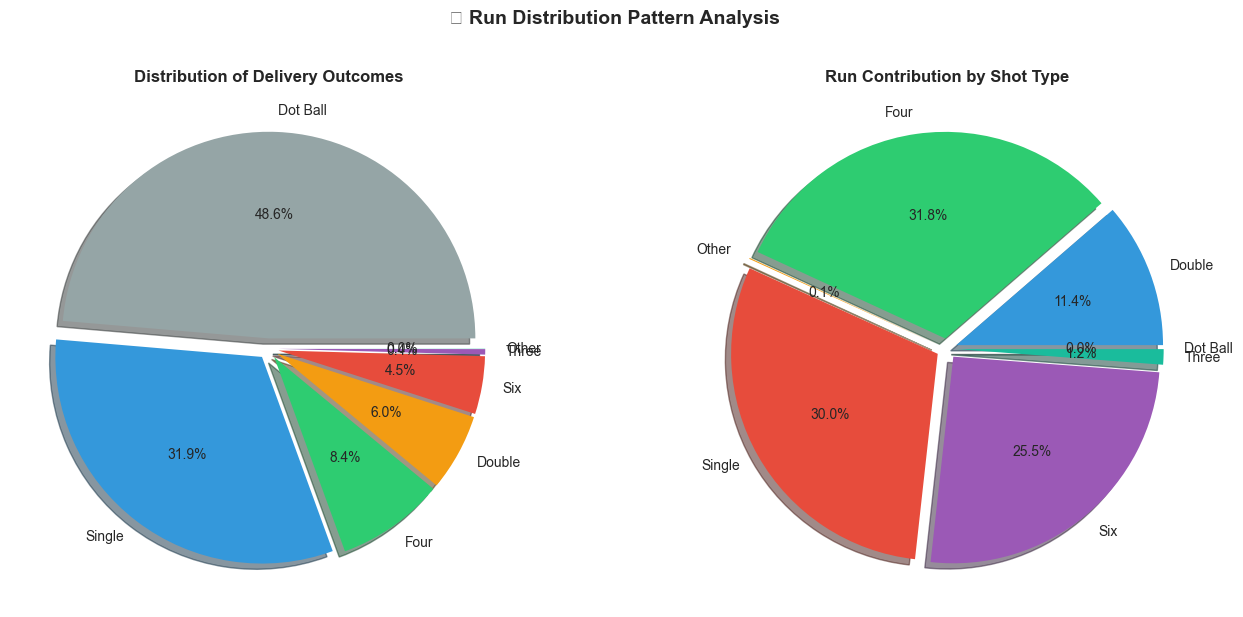


📊 Delivery Outcome Summary:
          Count
run_type       
Dot Ball   5581
Single     3661
Four        968
Double      692
Six         519
Three        49
Other         2

📊 Total Runs by Shot Type:
          Runs
run_type      
Dot Ball     0
Double    1384
Four      3872
Other       10
Single    3661
Six       3114
Three      147


In [13]:
# Overall run distribution in the tournament
def categorize_runs(runs):
    if runs == 0:
        return 'Dot Ball'
    elif runs == 1:
        return 'Single'
    elif runs == 2:
        return 'Double'
    elif runs == 3:
        return 'Three'
    elif runs == 4:
        return 'Four'
    elif runs == 6:
        return 'Six'
    else:
        return 'Other'

deliveries['run_type'] = deliveries['runs_off_bat'].apply(categorize_runs)
run_distribution = deliveries['run_type'].value_counts()

# Calculate total runs from each type
run_contribution = deliveries.groupby('run_type')['runs_off_bat'].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart for deliveries
colors = ['#95a5a6', '#3498db', '#2ecc71', '#f39c12', '#e74c3c', '#9b59b6', '#1abc9c']
axes[0].pie(run_distribution, labels=run_distribution.index, autopct='%1.1f%%', 
            colors=colors, explode=[0.05] * len(run_distribution), shadow=True)
axes[0].set_title('Distribution of Delivery Outcomes', fontsize=12, fontweight='bold')

# Pie chart for run contribution
axes[1].pie(run_contribution, labels=run_contribution.index, autopct='%1.1f%%', 
            colors=colors, explode=[0.05] * len(run_contribution), shadow=True)
axes[1].set_title('Run Contribution by Shot Type', fontsize=12, fontweight='bold')

plt.suptitle('📊 Run Distribution Pattern Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n📊 Delivery Outcome Summary:")
print(run_distribution.to_frame(name='Count'))
print(f"\n📊 Total Runs by Shot Type:")
print(run_contribution.to_frame(name='Runs'))

---
## 📈 Consistency & Player Role Analysis

## 10. Batting Consistency Analysis (Mean Runs vs Variability)

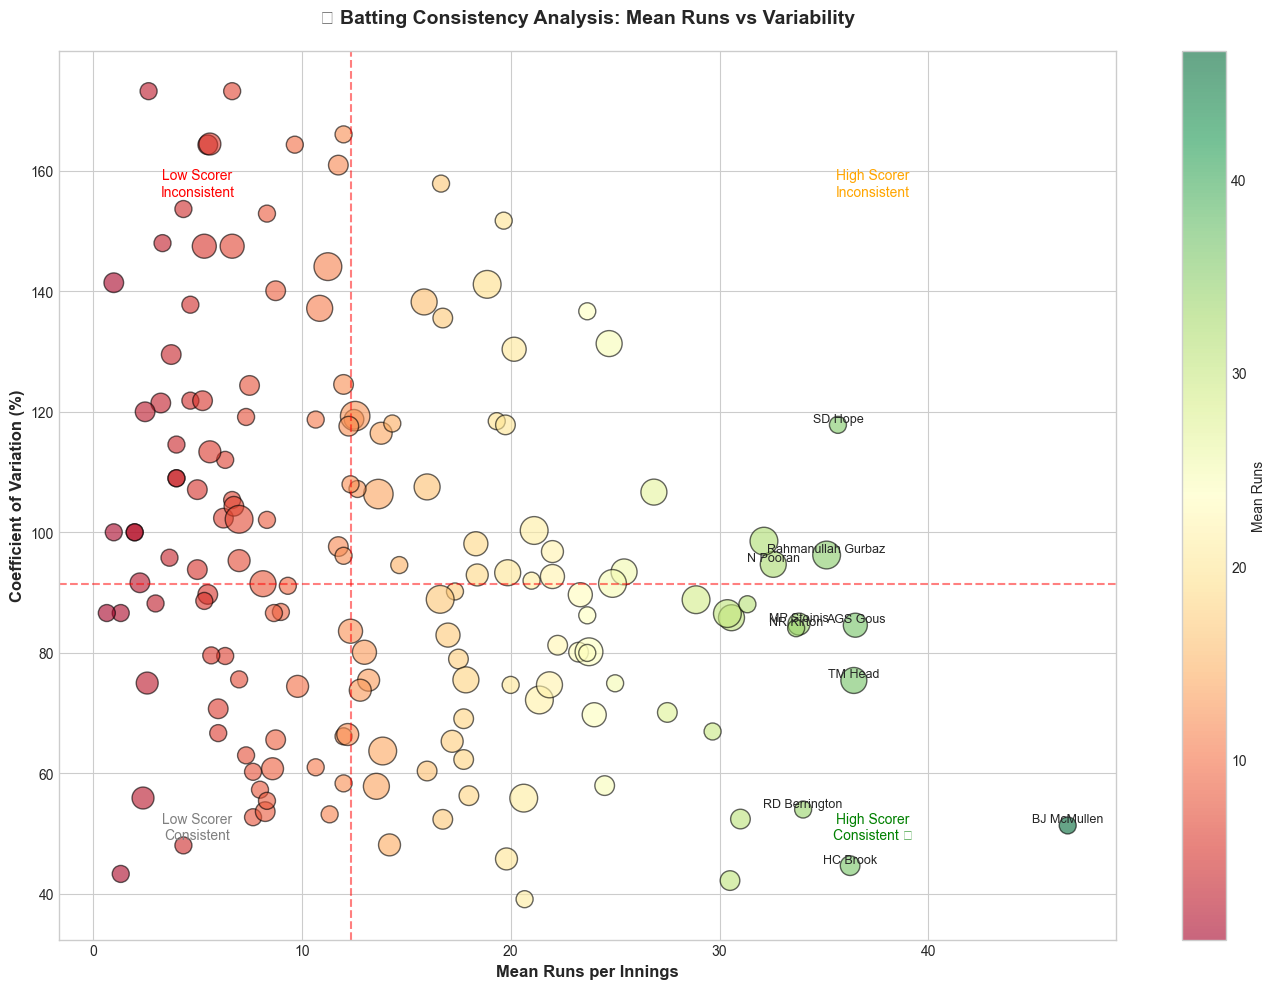


📊 Most Consistent High Scorers (High Mean, Low CV):


,player,mean_runs,std_runs,innings,cv
35,BJ McMullen,46.666667,23.965253,3,51.35
11,AGS Gous,36.500000,30.872318,6,84.58
232,TM Head,36.428571,27.470330,7,75.41
74,HC Brook,36.250000,16.194135,4,44.67
186,RD Berrington,34.000000,18.357560,3,53.99
140,MP Stoinis,33.800000,28.647862,5,84.76
159,NR Kirton,33.666667,28.307832,3,84.08
191,RL Chase,31.333333,27.592269,3,88.06
75,HG Munsey,31.000000,16.248077,4,52.41
89,JC Buttler,30.571429,26.235200,7,85.82


In [14]:
# Calculate consistency metrics for each batsman
consistency_stats = innings_scores.groupby('player').agg({
    'runs': ['mean', 'std', 'count']
}).reset_index()
consistency_stats.columns = ['player', 'mean_runs', 'std_runs', 'innings']

# Filter for players with at least 3 innings
consistency_stats = consistency_stats[consistency_stats['innings'] >= 3]
consistency_stats['std_runs'] = consistency_stats['std_runs'].fillna(0)
consistency_stats['cv'] = (consistency_stats['std_runs'] / consistency_stats['mean_runs'] * 100).round(2)

# Create scatter plot
fig, ax = plt.subplots(figsize=(14, 10))

scatter = ax.scatter(consistency_stats['mean_runs'], consistency_stats['cv'], 
                     s=consistency_stats['innings'] * 50, alpha=0.6,
                     c=consistency_stats['mean_runs'], cmap='RdYlGn', edgecolors='black')

# Add labels for top performers
top_performers = consistency_stats.nlargest(10, 'mean_runs')
for _, row in top_performers.iterrows():
    ax.annotate(row['player'], (row['mean_runs'], row['cv']), 
                fontsize=9, ha='center', va='bottom')

# Add quadrant lines
ax.axhline(consistency_stats['cv'].median(), color='red', linestyle='--', alpha=0.5)
ax.axvline(consistency_stats['mean_runs'].median(), color='red', linestyle='--', alpha=0.5)

# Add quadrant labels
ax.text(consistency_stats['mean_runs'].max() * 0.8, consistency_stats['cv'].max() * 0.9, 
        'High Scorer\nInconsistent', fontsize=10, ha='center', color='orange')
ax.text(consistency_stats['mean_runs'].max() * 0.8, consistency_stats['cv'].min() + 10, 
        'High Scorer\nConsistent ✅', fontsize=10, ha='center', color='green')
ax.text(consistency_stats['mean_runs'].min() + 5, consistency_stats['cv'].max() * 0.9, 
        'Low Scorer\nInconsistent', fontsize=10, ha='center', color='red')
ax.text(consistency_stats['mean_runs'].min() + 5, consistency_stats['cv'].min() + 10, 
        'Low Scorer\nConsistent', fontsize=10, ha='center', color='gray')

ax.set_xlabel('Mean Runs per Innings', fontsize=12, fontweight='bold')
ax.set_ylabel('Coefficient of Variation (%)', fontsize=12, fontweight='bold')
ax.set_title('📈 Batting Consistency Analysis: Mean Runs vs Variability', fontsize=14, fontweight='bold', pad=20)
plt.colorbar(scatter, label='Mean Runs')
plt.tight_layout()
plt.show()

print("\n📊 Most Consistent High Scorers (High Mean, Low CV):")
consistent_scorers = consistency_stats[(consistency_stats['mean_runs'] > consistency_stats['mean_runs'].median()) & 
                                       (consistency_stats['cv'] < consistency_stats['cv'].median())]
display(consistent_scorers.sort_values('mean_runs', ascending=False).head(10))

## 11. Anchor vs Aggressive Batsmen Comparison

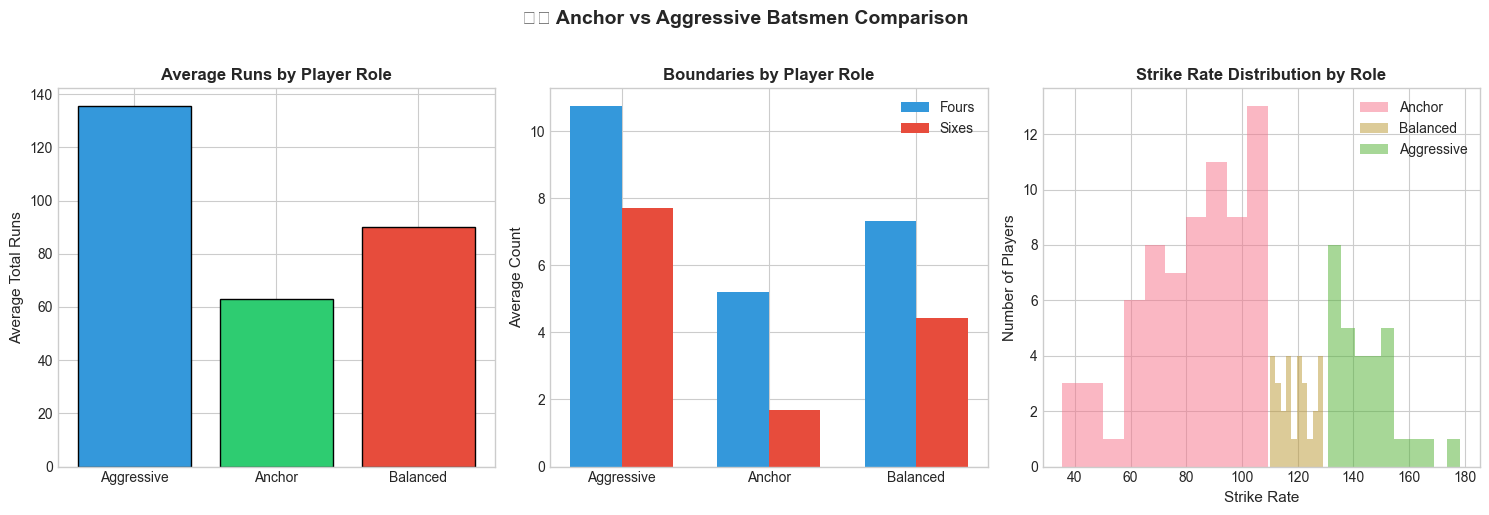


📊 Role-wise Statistics:


,Avg Runs,Batting Avg,Strike Rate,Avg Fours,Avg Sixes,Boundary %,Count
role,,,,,,,
Aggressive,135.40,35.43,144.33,10.73,7.70,64.57,30
Anchor,63.16,15.67,82.75,5.21,1.69,46.44,70
Balanced,90.14,24.49,119.20,7.32,4.43,60.89,28


In [15]:
# Classify batsmen as Anchor or Aggressive based on strike rate
qualified_for_role = batting_stats[batting_stats['balls_faced'] >= 30].copy()

def classify_role(sr):
    if sr < 110:
        return 'Anchor'
    elif sr < 130:
        return 'Balanced'
    else:
        return 'Aggressive'

qualified_for_role['role'] = qualified_for_role['strike_rate'].apply(classify_role)

# Compare metrics by role
role_comparison = qualified_for_role.groupby('role').agg({
    'total_runs': 'mean',
    'batting_average': 'mean',
    'strike_rate': 'mean',
    'fours': 'mean',
    'sixes': 'mean',
    'boundary_pct': 'mean',
    'player': 'count'
}).round(2)
role_comparison.columns = ['Avg Runs', 'Batting Avg', 'Strike Rate', 'Avg Fours', 'Avg Sixes', 'Boundary %', 'Count']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Total Runs Comparison
role_runs = qualified_for_role.groupby('role')['total_runs'].mean()
axes[0].bar(role_runs.index, role_runs.values, color=['#3498db', '#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_ylabel('Average Total Runs', fontsize=11)
axes[0].set_title('Average Runs by Player Role', fontsize=12, fontweight='bold')

# Plot 2: Boundary Count Comparison
boundary_by_role = qualified_for_role.groupby('role')[['fours', 'sixes']].mean()
x = np.arange(len(boundary_by_role))
width = 0.35
axes[1].bar(x - width/2, boundary_by_role['fours'], width, label='Fours', color='#3498db')
axes[1].bar(x + width/2, boundary_by_role['sixes'], width, label='Sixes', color='#e74c3c')
axes[1].set_xticks(x)
axes[1].set_xticklabels(boundary_by_role.index)
axes[1].set_ylabel('Average Count', fontsize=11)
axes[1].set_title('Boundaries by Player Role', fontsize=12, fontweight='bold')
axes[1].legend()

# Plot 3: Strike Rate Distribution by Role
for role in ['Anchor', 'Balanced', 'Aggressive']:
    data = qualified_for_role[qualified_for_role['role'] == role]['strike_rate']
    axes[2].hist(data, alpha=0.5, label=role, bins=10)
axes[2].set_xlabel('Strike Rate', fontsize=11)
axes[2].set_ylabel('Number of Players', fontsize=11)
axes[2].set_title('Strike Rate Distribution by Role', fontsize=12, fontweight='bold')
axes[2].legend()

plt.suptitle('⚔️ Anchor vs Aggressive Batsmen Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n📊 Role-wise Statistics:")
display(role_comparison)

## 12. Player Impact Score Analysis (Runs × Strike Rate)

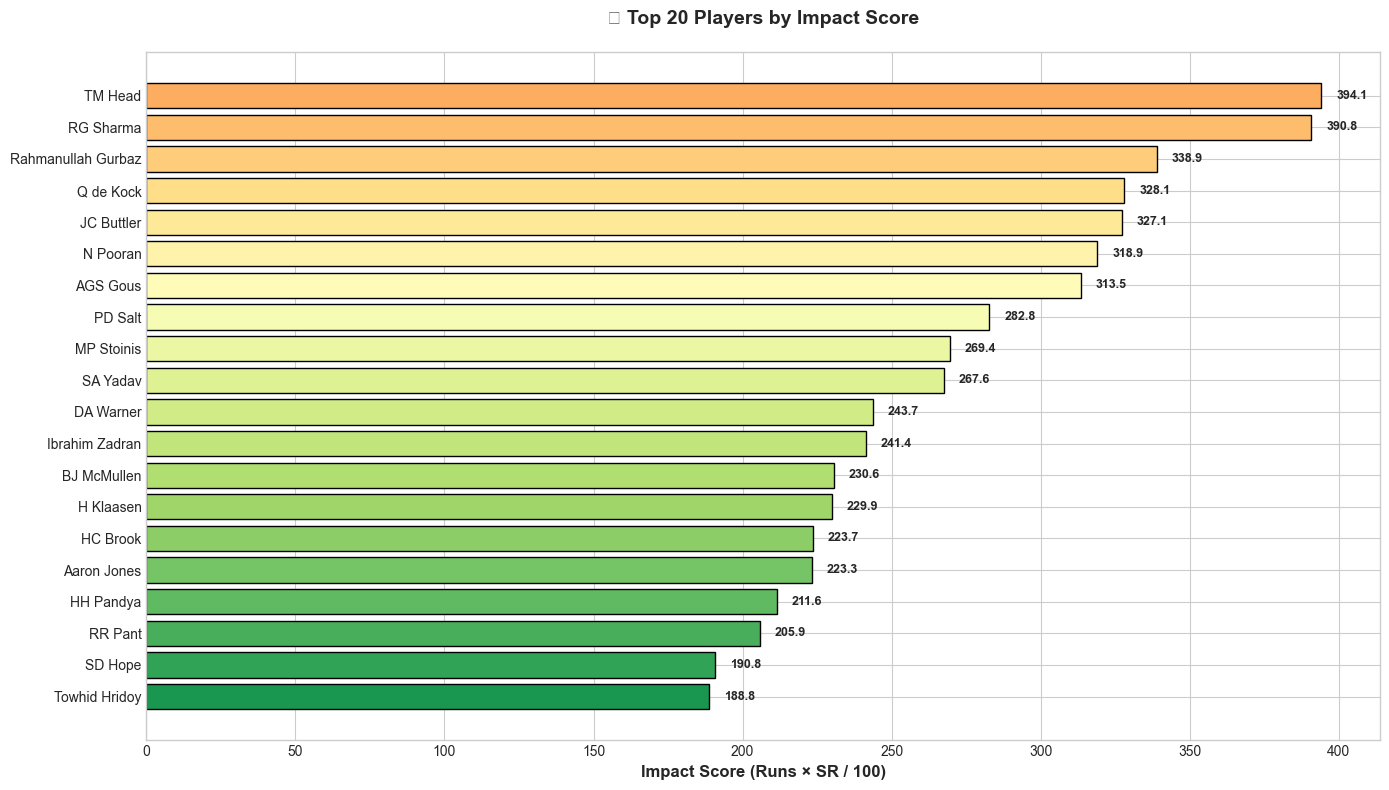


📊 Top 20 Impact Players:


,player,total_runs,balls_faced,strike_rate,impact_score
0,TM Head,255,165,154.55,394.10
1,RG Sharma,257,169,152.07,390.82
2,Rahmanullah Gurbaz,281,233,120.60,338.89
3,Q de Kock,243,180,135.00,328.05
4,JC Buttler,214,140,152.86,327.12
5,N Pooran,228,163,139.88,318.93
6,AGS Gous,219,153,143.14,313.48
7,PD Salt,188,125,150.40,282.75
8,MP Stoinis,169,106,159.43,269.44
9,SA Yadav,199,148,134.46,267.58


In [16]:
# Calculate Impact Score
impact_df = batting_stats[batting_stats['balls_faced'] >= 30].copy()
impact_df['impact_score'] = (impact_df['total_runs'] * impact_df['strike_rate'] / 100).round(2)

# Get top 20 impact players
top_impact = impact_df.nlargest(20, 'impact_score')

# Create bubble chart
fig = px.scatter(top_impact, 
                 x='total_runs', 
                 y='strike_rate',
                 size='impact_score',
                 color='impact_score',
                 hover_name='player',
                 text='player',
                 color_continuous_scale='RdYlGn',
                 title='🎯 Player Impact Score Analysis (Runs × Strike Rate)')

fig.update_traces(textposition='top center', textfont_size=9)
fig.update_layout(
    xaxis_title='Total Runs',
    yaxis_title='Strike Rate',
    height=600,
    width=1000
)
fig.show()

# Bar chart of top impact players
fig2, ax = plt.subplots(figsize=(14, 8))
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(top_impact)))
bars = ax.barh(top_impact['player'], top_impact['impact_score'], color=colors, edgecolor='black')
ax.set_xlabel('Impact Score (Runs × SR / 100)', fontsize=12, fontweight='bold')
ax.set_title('🏆 Top 20 Players by Impact Score', fontsize=14, fontweight='bold', pad=20)
ax.invert_yaxis()

for bar, score in zip(bars, top_impact['impact_score']):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2, 
            f'{score:.1f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📊 Top 20 Impact Players:")
display(top_impact[['player', 'total_runs', 'balls_faced', 'strike_rate', 'impact_score']].reset_index(drop=True))

---
## 🏆 Match Context Batting Analysis

## 13. Batting Performance in Winning vs Losing Matches

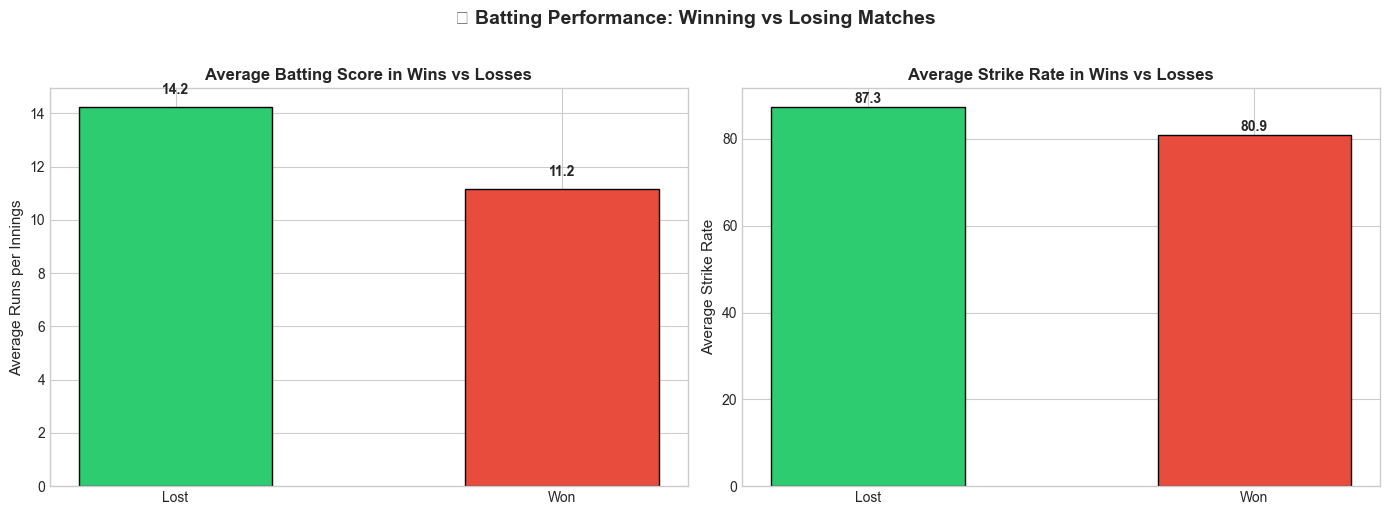


📊 Overall Batting Stats - Wins vs Losses:


runs        strike_rate
         mean    sum        mean
result                          
Lost    14.23  10641       87.29
Won     11.16    212       80.92

In [17]:
# Create match result mapping
match_results = matches[['match_number', 'winner', 'team1', 'team2']].copy()

# Calculate innings scores and merge with results
innings_with_results = innings_scores.merge(match_results, left_on='match_id', right_on='match_number', how='left')
innings_with_results['result'] = innings_with_results.apply(
    lambda x: 'Won' if x['team'] == x['winner'] else ('Lost' if pd.notna(x['winner']) else 'No Result'), axis=1
)

# Filter out No Results
win_loss_batting = innings_with_results[innings_with_results['result'].isin(['Won', 'Lost'])]

# Group by player and result
player_wl_stats = win_loss_batting.groupby(['player', 'result']).agg({
    'runs': ['sum', 'mean', 'count'],
    'balls': 'sum',
    'strike_rate': 'mean'
}).reset_index()
player_wl_stats.columns = ['player', 'result', 'total_runs', 'avg_runs', 'innings', 'balls', 'avg_sr']

# Pivot for comparison
win_stats = player_wl_stats[player_wl_stats['result'] == 'Won'].set_index('player')
loss_stats = player_wl_stats[player_wl_stats['result'] == 'Lost'].set_index('player')

# Overall comparison
overall_wl = win_loss_batting.groupby('result').agg({
    'runs': ['mean', 'sum'],
    'strike_rate': 'mean'
}).round(2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Average runs in wins vs losses
wl_summary = win_loss_batting.groupby('result')['runs'].mean()
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(wl_summary.index, wl_summary.values, color=colors, edgecolor='black', width=0.5)
axes[0].set_ylabel('Average Runs per Innings', fontsize=11)
axes[0].set_title('Average Batting Score in Wins vs Losses', fontsize=12, fontweight='bold')
for i, v in enumerate(wl_summary.values):
    axes[0].text(i, v + 0.5, f'{v:.1f}', ha='center', fontweight='bold')

# Strike rate comparison
sr_summary = win_loss_batting.groupby('result')['strike_rate'].mean()
axes[1].bar(sr_summary.index, sr_summary.values, color=colors, edgecolor='black', width=0.5)
axes[1].set_ylabel('Average Strike Rate', fontsize=11)
axes[1].set_title('Average Strike Rate in Wins vs Losses', fontsize=12, fontweight='bold')
for i, v in enumerate(sr_summary.values):
    axes[1].text(i, v + 1, f'{v:.1f}', ha='center', fontweight='bold')

plt.suptitle('🏆 Batting Performance: Winning vs Losing Matches', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n📊 Overall Batting Stats - Wins vs Losses:")
display(overall_wl)

## 14. Group Stage vs Knockout Stage Batting Performance

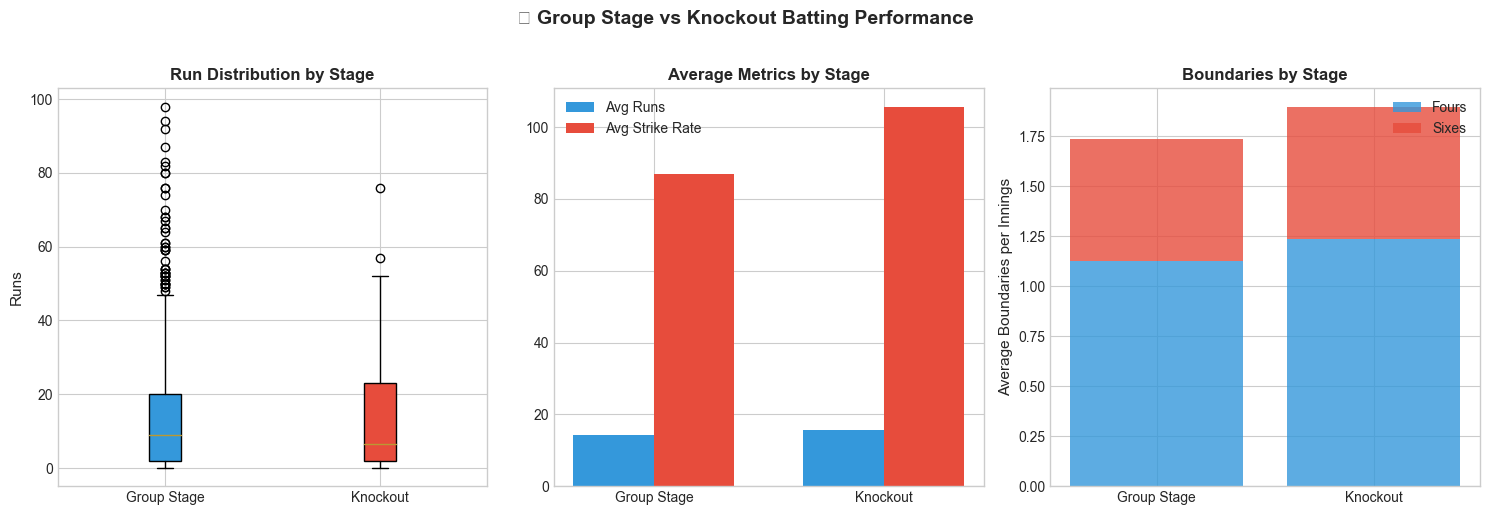


📊 Stage-wise Batting Statistics:


runs              strike_rate fours sixes
              mean    sum count        mean  mean  mean
stage                                                  
Group Stage  14.20  11590   816       87.03  1.13  0.61
Knockout     15.74    598    38      105.49  1.24  0.66

In [18]:
# Merge match type with deliveries
match_type_df = matches[['match_number', 'match_type']].copy()
innings_with_stage = innings_scores.merge(match_type_df, left_on='match_id', right_on='match_number', how='left')

# Create stage classification
innings_with_stage['stage'] = innings_with_stage['match_type'].apply(
    lambda x: 'Knockout' if x in ['Semi Final', 'Final'] else 'Group Stage'
)

# Compare stages
stage_comparison = innings_with_stage.groupby('stage').agg({
    'runs': ['mean', 'sum', 'count'],
    'strike_rate': 'mean',
    'fours': 'mean',
    'sixes': 'mean'
}).round(2)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Box plot - Runs by stage
stage_data = [innings_with_stage[innings_with_stage['stage'] == s]['runs'] for s in ['Group Stage', 'Knockout']]
bp = axes[0].boxplot(stage_data, labels=['Group Stage', 'Knockout'], patch_artist=True)
bp['boxes'][0].set_facecolor('#3498db')
bp['boxes'][1].set_facecolor('#e74c3c')
axes[0].set_ylabel('Runs', fontsize=11)
axes[0].set_title('Run Distribution by Stage', fontsize=12, fontweight='bold')

# Average metrics comparison
stage_means = innings_with_stage.groupby('stage')[['runs', 'strike_rate']].mean()
x = np.arange(len(stage_means))
width = 0.35
axes[1].bar(x - width/2, stage_means['runs'], width, label='Avg Runs', color='#3498db')
axes[1].bar(x + width/2, stage_means['strike_rate'], width, label='Avg Strike Rate', color='#e74c3c')
axes[1].set_xticks(x)
axes[1].set_xticklabels(stage_means.index)
axes[1].set_title('Average Metrics by Stage', fontsize=12, fontweight='bold')
axes[1].legend()

# Boundaries comparison
boundary_means = innings_with_stage.groupby('stage')[['fours', 'sixes']].mean()
axes[2].bar(boundary_means.index, boundary_means['fours'], label='Fours', color='#3498db', alpha=0.8)
axes[2].bar(boundary_means.index, boundary_means['sixes'], bottom=boundary_means['fours'], 
           label='Sixes', color='#e74c3c', alpha=0.8)
axes[2].set_ylabel('Average Boundaries per Innings', fontsize=11)
axes[2].set_title('Boundaries by Stage', fontsize=12, fontweight='bold')
axes[2].legend()

plt.suptitle('📊 Group Stage vs Knockout Batting Performance', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n📊 Stage-wise Batting Statistics:")
display(stage_comparison)

## 15. Batting First vs Chasing Performance Comparison

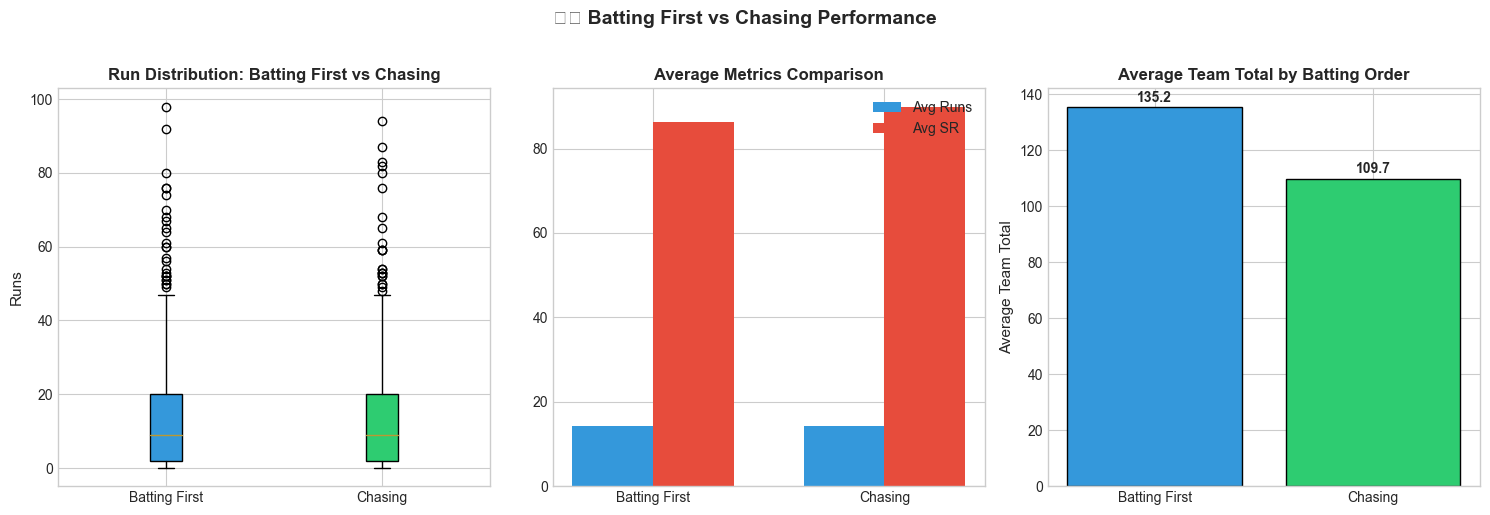


📊 Batting Order Statistics:


runs                    strike_rate fours sixes
                mean   sum count    std        mean  mean  mean
batting_order                                                  
Batting First  14.24  6577   462  17.25       86.23  1.13  0.61
Chasing        14.31  5611   392  16.72       89.77  1.14  0.61

In [19]:
# Classify batting order (1st innings = batting first, 2nd innings = chasing)
innings_with_order = innings_scores.copy()
innings_with_order['batting_order'] = innings_with_order['innings'].apply(
    lambda x: 'Batting First' if x == 1 else 'Chasing'
)

# Compare batting first vs chasing
order_comparison = innings_with_order.groupby('batting_order').agg({
    'runs': ['mean', 'sum', 'count', 'std'],
    'strike_rate': 'mean',
    'fours': 'mean',
    'sixes': 'mean'
}).round(2)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Box plot comparison
order_data = [innings_with_order[innings_with_order['batting_order'] == o]['runs'] 
              for o in ['Batting First', 'Chasing']]
bp = axes[0].boxplot(order_data, labels=['Batting First', 'Chasing'], patch_artist=True)
bp['boxes'][0].set_facecolor('#3498db')
bp['boxes'][1].set_facecolor('#2ecc71')
axes[0].set_ylabel('Runs', fontsize=11)
axes[0].set_title('Run Distribution: Batting First vs Chasing', fontsize=12, fontweight='bold')

# Mean runs and strike rate
order_means = innings_with_order.groupby('batting_order')[['runs', 'strike_rate']].mean()
x = np.arange(len(order_means))
width = 0.35
axes[1].bar(x - width/2, order_means['runs'], width, label='Avg Runs', color='#3498db')
axes[1].bar(x + width/2, order_means['strike_rate'], width, label='Avg SR', color='#e74c3c')
axes[1].set_xticks(x)
axes[1].set_xticklabels(order_means.index)
axes[1].set_title('Average Metrics Comparison', fontsize=12, fontweight='bold')
axes[1].legend()

# Total team innings runs
team_innings = deliveries.groupby(['match_id', 'innings', 'batting_team']).agg({
    'total_runs': 'sum'
}).reset_index()
team_innings['batting_order'] = team_innings['innings'].apply(
    lambda x: 'Batting First' if x == 1 else 'Chasing'
)
team_totals = team_innings.groupby('batting_order')['total_runs'].mean()
axes[2].bar(team_totals.index, team_totals.values, color=['#3498db', '#2ecc71'], edgecolor='black')
axes[2].set_ylabel('Average Team Total', fontsize=11)
axes[2].set_title('Average Team Total by Batting Order', fontsize=12, fontweight='bold')
for i, v in enumerate(team_totals.values):
    axes[2].text(i, v + 2, f'{v:.1f}', ha='center', fontweight='bold')

plt.suptitle('⚖️ Batting First vs Chasing Performance', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n📊 Batting Order Statistics:")
display(order_comparison)

---
## 🏏 Team Batting Strength Analysis

## 16. Team-wise Total Runs and Average Strike Rate

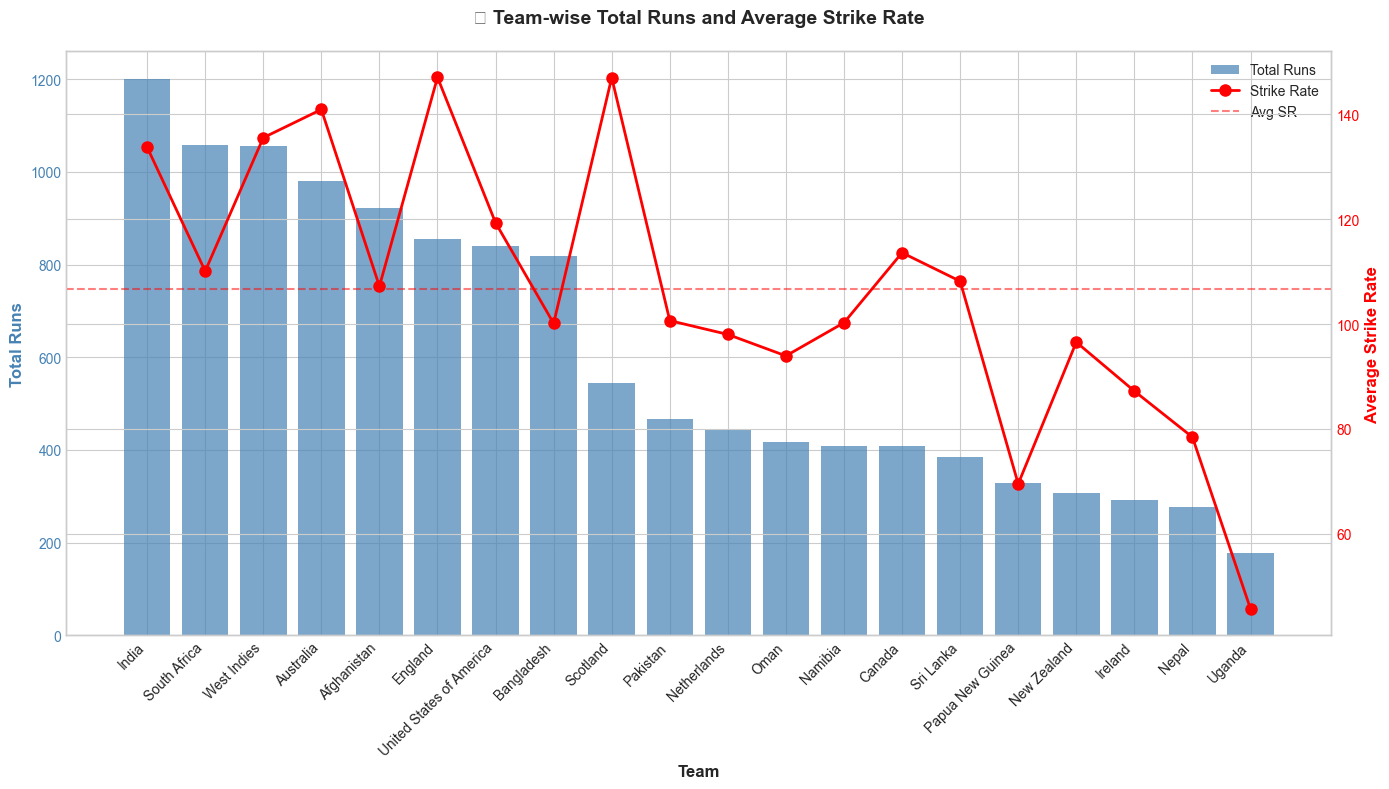


📊 Team Batting Summary:


,team,total_runs,matches,runs_per_match,strike_rate,fours,sixes
5,India,1201,8,150.12,133.74,92,61
15,South Africa,1058,9,117.56,110.09,82,43
19,West Indies,1056,7,150.86,135.56,81,62
1,Australia,981,7,140.14,140.95,91,50
0,Afghanistan,922,8,115.25,107.21,72,37
4,England,856,7,122.29,147.08,74,38
18,United States of America,840,6,140.00,119.32,62,42
2,Bangladesh,819,7,117.00,100.12,69,25
14,Scotland,544,4,136.00,147.03,34,34
12,Pakistan,467,4,116.75,100.65,29,17


In [20]:
# Team-wise batting statistics
team_batting = deliveries.groupby('batting_team').agg({
    'runs_off_bat': 'sum',
    'ball': 'count',
    'is_four': 'sum',
    'is_six': 'sum',
    'is_legal': 'sum',
    'match_id': 'nunique'
}).reset_index()

team_batting.columns = ['team', 'total_runs', 'balls', 'fours', 'sixes', 'legal_balls', 'matches']
team_batting['strike_rate'] = (team_batting['total_runs'] / team_batting['legal_balls'] * 100).round(2)
team_batting['runs_per_match'] = (team_batting['total_runs'] / team_batting['matches']).round(2)

# Sort by total runs
team_batting = team_batting.sort_values('total_runs', ascending=False)

# Create dual-axis chart
fig, ax1 = plt.subplots(figsize=(14, 8))

x = np.arange(len(team_batting))
bars = ax1.bar(x, team_batting['total_runs'], color='steelblue', alpha=0.7, label='Total Runs')
ax1.set_xlabel('Team', fontsize=12, fontweight='bold')
ax1.set_ylabel('Total Runs', fontsize=12, fontweight='bold', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_xticks(x)
ax1.set_xticklabels(team_batting['team'], rotation=45, ha='right')

ax2 = ax1.twinx()
line = ax2.plot(x, team_batting['strike_rate'], color='red', marker='o', linewidth=2, markersize=8, label='Strike Rate')
ax2.set_ylabel('Average Strike Rate', fontsize=12, fontweight='bold', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.axhline(team_batting['strike_rate'].mean(), color='red', linestyle='--', alpha=0.5, label='Avg SR')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title('🏏 Team-wise Total Runs and Average Strike Rate', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n📊 Team Batting Summary:")
display(team_batting[['team', 'total_runs', 'matches', 'runs_per_match', 'strike_rate', 'fours', 'sixes']])

## 17. Top-order vs Middle-order Contribution Analysis

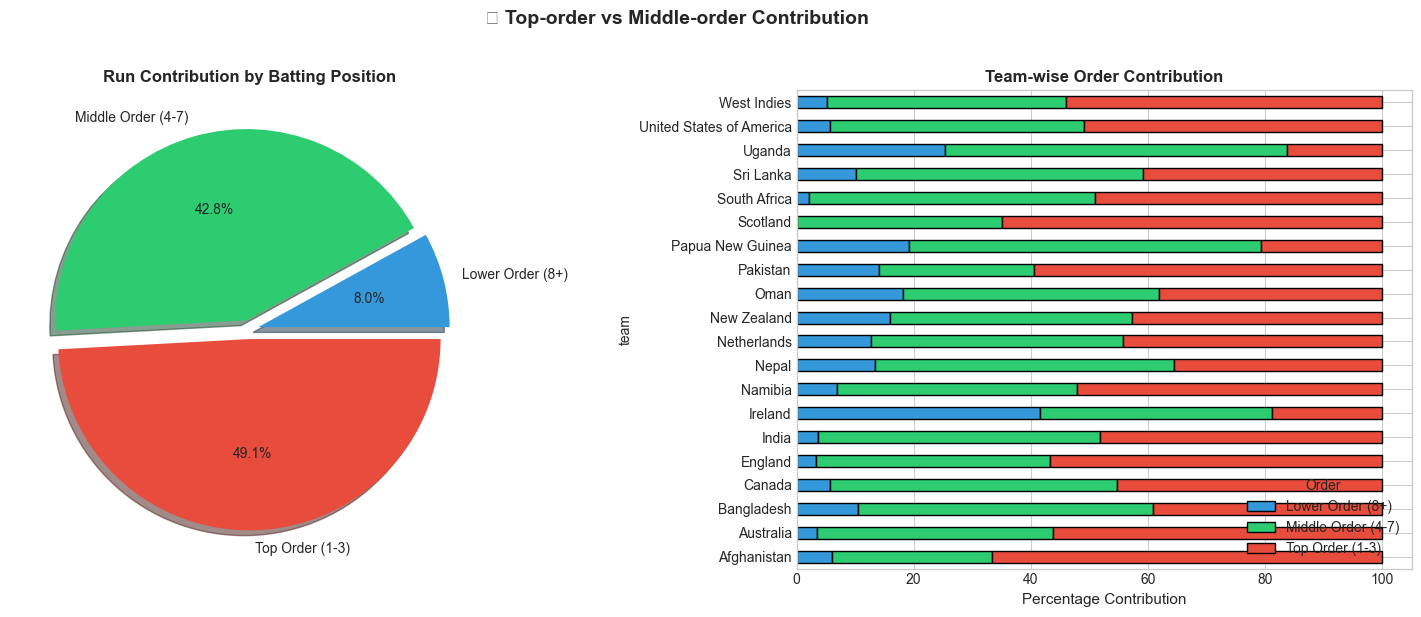


📊 Order-wise Statistics:


,Total Runs,Avg Runs,Innings,Avg SR
order_type,,,,
Lower Order (8+),977,5.37,182,70.80
Middle Order (4-7),5221,14.67,356,91.49
Top Order (1-3),5990,18.96,316,93.59


In [21]:
# Determine batting position based on order of appearance in each innings
batting_order_df = deliveries.groupby(['match_id', 'innings', 'batting_team', 'striker']).agg({
    'ball': 'min'
}).reset_index()

batting_order_df = batting_order_df.sort_values(['match_id', 'innings', 'ball'])
batting_order_df['batting_position'] = batting_order_df.groupby(['match_id', 'innings']).cumcount() + 1

# Classify as top-order (1-3) or middle-order (4-7) or lower-order (8+)
def classify_position(pos):
    if pos <= 3:
        return 'Top Order (1-3)'
    elif pos <= 7:
        return 'Middle Order (4-7)'
    else:
        return 'Lower Order (8+)'

batting_order_df['order_type'] = batting_order_df['batting_position'].apply(classify_position)

# Merge with full innings scores
innings_with_position = innings_scores.merge(
    batting_order_df[['match_id', 'innings', 'striker', 'batting_position', 'order_type']],
    left_on=['match_id', 'innings', 'player'],
    right_on=['match_id', 'innings', 'striker'],
    how='left'
)

# Calculate contribution by order type
order_contribution = innings_with_position.groupby('order_type').agg({
    'runs': ['sum', 'mean', 'count'],
    'strike_rate': 'mean'
}).round(2)

order_contribution.columns = ['Total Runs', 'Avg Runs', 'Innings', 'Avg SR']

# Team-wise contribution by order
team_order_contribution = innings_with_position.groupby(['team', 'order_type'])['runs'].sum().unstack(fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Overall contribution pie chart
order_totals = innings_with_position.groupby('order_type')['runs'].sum()
colors = ['#3498db', '#2ecc71', '#e74c3c']
axes[0].pie(order_totals, labels=order_totals.index, autopct='%1.1f%%', colors=colors, 
            explode=[0.05]*len(order_totals), shadow=True)
axes[0].set_title('Run Contribution by Batting Position', fontsize=12, fontweight='bold')

# Team-wise stacked bar chart
team_order_contribution_pct = team_order_contribution.div(team_order_contribution.sum(axis=1), axis=0) * 100
team_order_contribution_pct.plot(kind='barh', stacked=True, ax=axes[1], color=colors, edgecolor='black')
axes[1].set_xlabel('Percentage Contribution', fontsize=11)
axes[1].set_title('Team-wise Order Contribution', fontsize=12, fontweight='bold')
axes[1].legend(title='Order', loc='lower right')

plt.suptitle('📊 Top-order vs Middle-order Contribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n📊 Order-wise Statistics:")
display(order_contribution)

## 18. Dependency on Key Batsmen Within Each Team

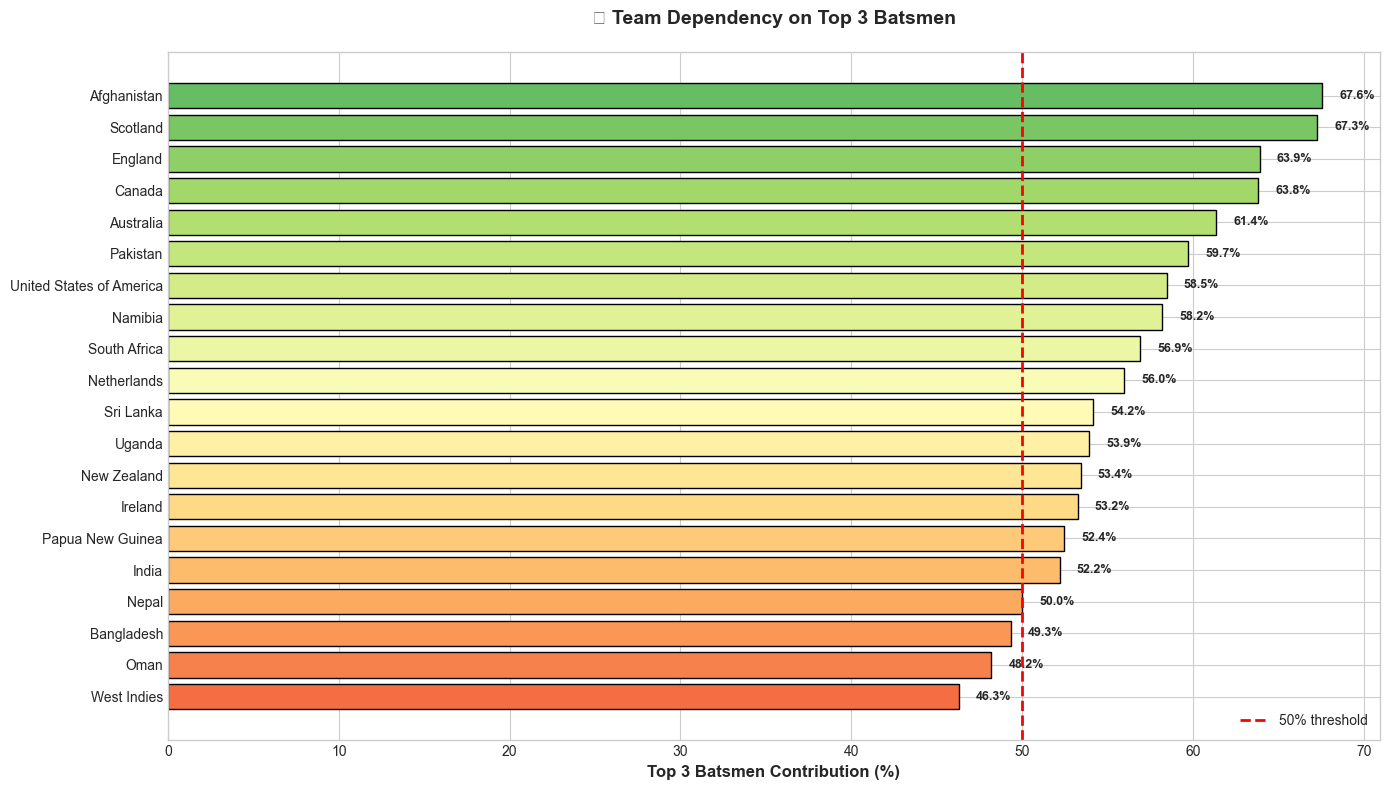


📊 Team Dependency Summary:


,team,top3_contribution
0,Afghanistan,67.57
14,Scotland,67.28
4,England,63.90
3,Canada,63.81
1,Australia,61.36
12,Pakistan,59.73
18,United States of America,58.46
7,Namibia,58.19
15,South Africa,56.90
9,Netherlands,55.98


In [22]:
# Calculate player runs by team
player_team_runs = innings_scores.groupby(['team', 'player'])['runs'].sum().reset_index()
team_totals = player_team_runs.groupby('team')['runs'].sum().reset_index()
team_totals.columns = ['team', 'team_total']

player_team_runs = player_team_runs.merge(team_totals, on='team')
player_team_runs['contribution_pct'] = (player_team_runs['runs'] / player_team_runs['team_total'] * 100).round(2)

# Get top 3 batsmen for each team
top3_by_team = player_team_runs.sort_values(['team', 'runs'], ascending=[True, False]).groupby('team').head(3)

# Calculate dependency (top 3 contribution %)
team_dependency = top3_by_team.groupby('team')['contribution_pct'].sum().reset_index()
team_dependency.columns = ['team', 'top3_contribution']
team_dependency = team_dependency.sort_values('top3_contribution', ascending=False)

# Create treemap data
treemap_data = []
for team in top3_by_team['team'].unique():
    team_players = top3_by_team[top3_by_team['team'] == team]
    for _, row in team_players.iterrows():
        treemap_data.append({
            'team': row['team'],
            'player': row['player'],
            'runs': row['runs'],
            'contribution': row['contribution_pct']
        })

treemap_df = pd.DataFrame(treemap_data)

# Create treemap
fig = px.treemap(treemap_df, 
                 path=['team', 'player'],
                 values='runs',
                 color='contribution',
                 color_continuous_scale='RdYlGn',
                 title='🏏 Team Dependency on Key Batsmen (Top 3 Contributors)')
fig.update_layout(height=700, width=1000)
fig.show()

# Bar chart of team dependency
fig2, ax = plt.subplots(figsize=(14, 8))
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(team_dependency)))
bars = ax.barh(team_dependency['team'], team_dependency['top3_contribution'], color=colors, edgecolor='black')
ax.axvline(50, color='red', linestyle='--', linewidth=2, label='50% threshold')
ax.set_xlabel('Top 3 Batsmen Contribution (%)', fontsize=12, fontweight='bold')
ax.set_title('📊 Team Dependency on Top 3 Batsmen', fontsize=14, fontweight='bold', pad=20)
ax.invert_yaxis()
ax.legend()

for bar, val in zip(bars, team_dependency['top3_contribution']):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📊 Team Dependency Summary:")
display(team_dependency)

---
# 🎯 PART 2: BOWLING PERFORMANCE ANALYSIS
---

## 19. Top Wicket-Takers in the Tournament

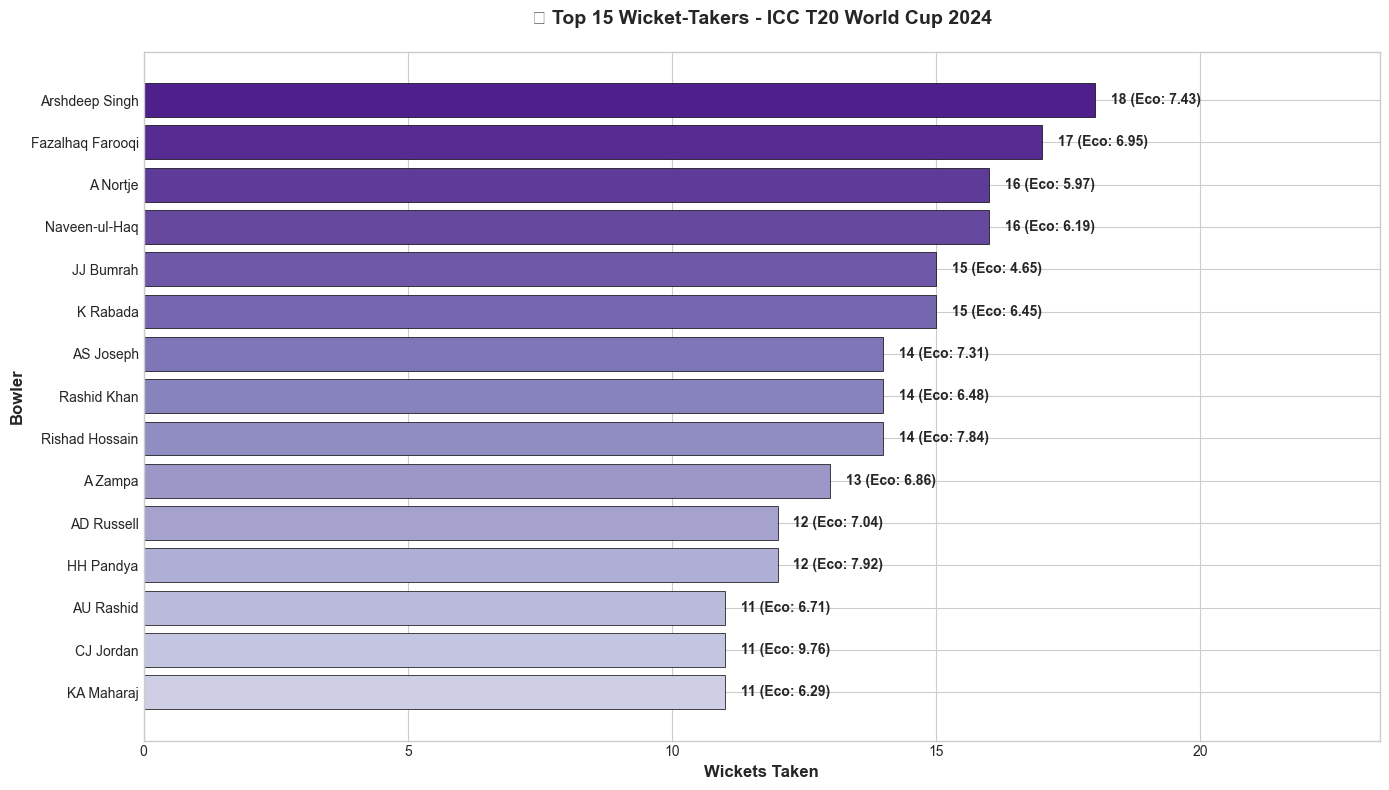


📊 Top 15 Wicket-Takers Summary:


,bowler,wickets,matches,overs,runs_conceded,economy_rate,bowling_average
18,Arshdeep Singh,18,8,30.0,223,7.43,12.39
48,Fazalhaq Farooqi,17,8,25.2,176,6.95,10.35
3,A Nortje,16,9,35.0,209,5.97,13.06
117,Naveen-ul-Haq,16,8,26.4,165,6.19,10.31
67,JJ Bumrah,15,8,29.4,138,4.65,9.20
74,K Rabada,15,9,31.0,200,6.45,13.33
13,AS Joseph,14,7,24.3,179,7.31,12.79
132,Rashid Khan,14,8,29.0,188,6.48,13.43
134,Rishad Hossain,14,7,25.0,196,7.84,14.00
5,A Zampa,13,7,28.0,192,6.86,14.77


In [23]:
# Top 15 Wicket Takers
top_wicket_takers = bowling_stats.nlargest(15, 'wickets')

fig, ax = plt.subplots(figsize=(14, 8))
colors = plt.cm.Purples(np.linspace(0.3, 0.9, 15))[::-1]
bars = ax.barh(top_wicket_takers['bowler'], top_wicket_takers['wickets'], color=colors, edgecolor='black', linewidth=0.5)

# Add value labels
for bar, wickets, eco in zip(bars, top_wicket_takers['wickets'], top_wicket_takers['economy_rate']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, 
            f'{int(wickets)} (Eco: {eco})', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Wickets Taken', fontsize=12, fontweight='bold')
ax.set_ylabel('Bowler', fontsize=12, fontweight='bold')
ax.set_title('🎯 Top 15 Wicket-Takers - ICC T20 World Cup 2024', fontsize=14, fontweight='bold', pad=20)
ax.invert_yaxis()
ax.set_xlim(0, max(top_wicket_takers['wickets']) * 1.3)
plt.tight_layout()
plt.show()

print("\n📊 Top 15 Wicket-Takers Summary:")
display(top_wicket_takers[['bowler', 'wickets', 'matches', 'overs', 'runs_conceded', 'economy_rate', 'bowling_average']])

## 20. Bowling Average Distribution Across Bowlers

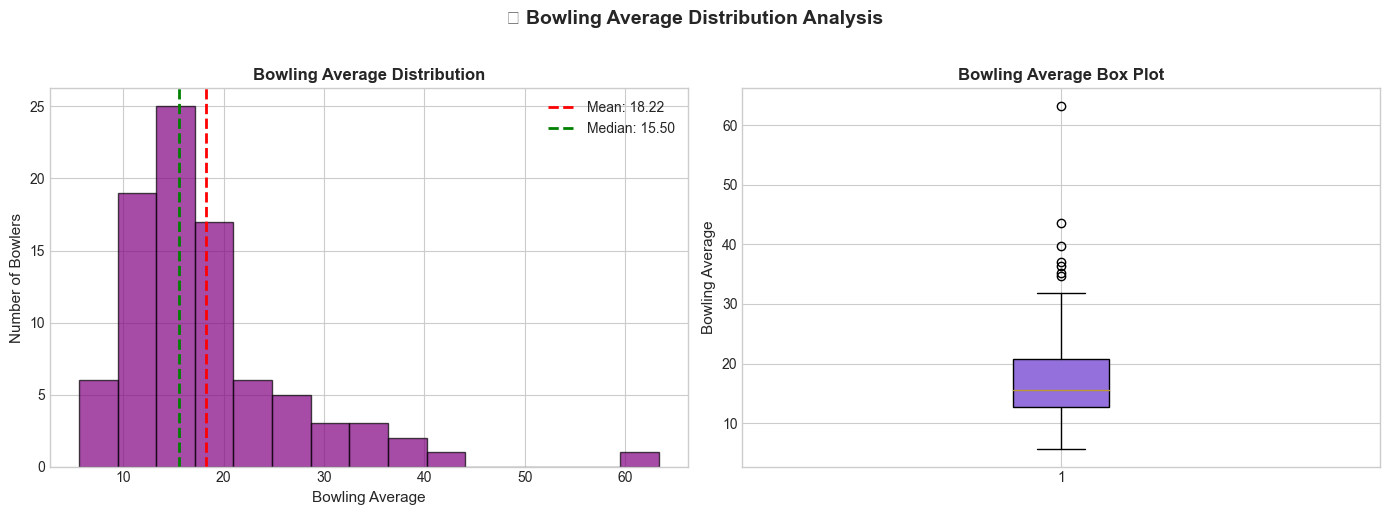


📈 Bowling Average Statistics (min 3 wickets):
   Mean: 18.22
   Median: 15.50
   Best: 5.57 (TG Southee)


In [24]:
# Filter bowlers with at least 3 wickets for meaningful average
qualified_bowlers = bowling_stats[(bowling_stats['wickets'] >= 3)].copy()
qualified_bowlers = qualified_bowlers[qualified_bowlers['bowling_average'].notna()]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(qualified_bowlers['bowling_average'], bins=15, color='purple', edgecolor='black', alpha=0.7)
axes[0].axvline(qualified_bowlers['bowling_average'].mean(), color='red', linestyle='--', linewidth=2, 
                label=f"Mean: {qualified_bowlers['bowling_average'].mean():.2f}")
axes[0].axvline(qualified_bowlers['bowling_average'].median(), color='green', linestyle='--', linewidth=2, 
                label=f"Median: {qualified_bowlers['bowling_average'].median():.2f}")
axes[0].set_xlabel('Bowling Average', fontsize=11)
axes[0].set_ylabel('Number of Bowlers', fontsize=11)
axes[0].set_title('Bowling Average Distribution', fontsize=12, fontweight='bold')
axes[0].legend()

# Box Plot
box_data = axes[1].boxplot(qualified_bowlers['bowling_average'], vert=True, patch_artist=True)
box_data['boxes'][0].set_facecolor('mediumpurple')
axes[1].set_ylabel('Bowling Average', fontsize=11)
axes[1].set_title('Bowling Average Box Plot', fontsize=12, fontweight='bold')

plt.suptitle('📊 Bowling Average Distribution Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\n📈 Bowling Average Statistics (min 3 wickets):")
print(f"   Mean: {qualified_bowlers['bowling_average'].mean():.2f}")
print(f"   Median: {qualified_bowlers['bowling_average'].median():.2f}")
print(f"   Best: {qualified_bowlers['bowling_average'].min():.2f} ({qualified_bowlers.loc[qualified_bowlers['bowling_average'].idxmin(), 'bowler']})")

## 21. Economy Rate Distribution Analysis

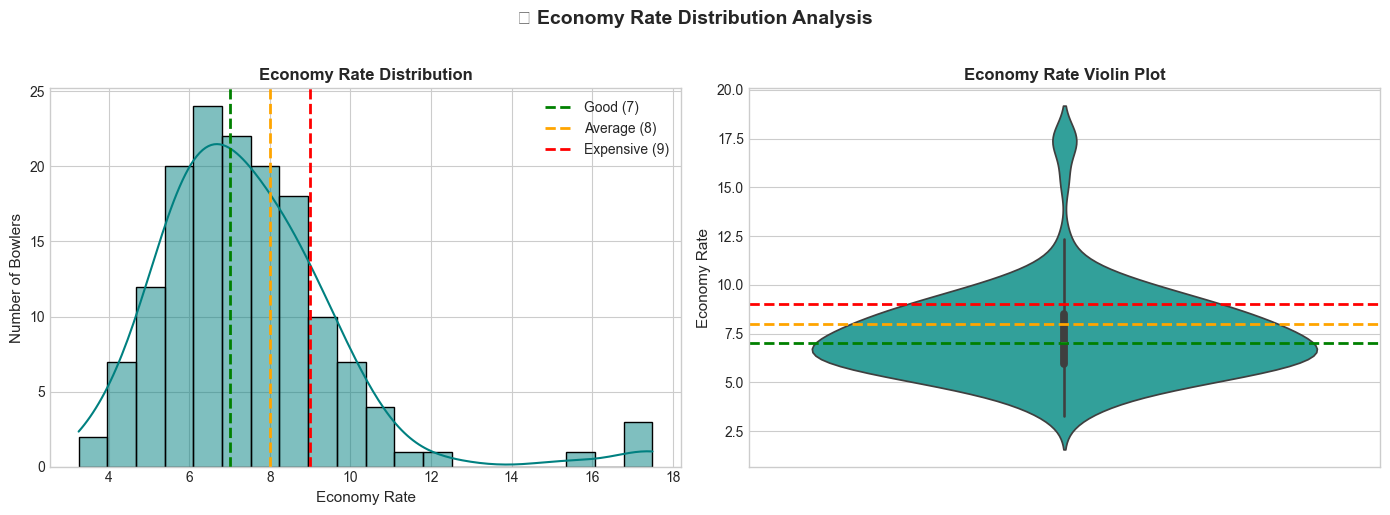


📊 Economy Rate Categories:
eco_category
Excellent (<6)     40
Good (6-7)         35
Average (7-8)      26
Below Avg (8-9)    26
Expensive (9+)     21
Name: count, dtype: int64


In [25]:
# Filter bowlers with minimum 12 balls (2 overs)
eco_qualified = bowling_stats[bowling_stats['legal_balls'] >= 12].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with KDE
sns.histplot(eco_qualified['economy_rate'], kde=True, color='teal', ax=axes[0], bins=20)
axes[0].axvline(7, color='green', linestyle='--', linewidth=2, label='Good (7)')
axes[0].axvline(8, color='orange', linestyle='--', linewidth=2, label='Average (8)')
axes[0].axvline(9, color='red', linestyle='--', linewidth=2, label='Expensive (9)')
axes[0].set_xlabel('Economy Rate', fontsize=11)
axes[0].set_ylabel('Number of Bowlers', fontsize=11)
axes[0].set_title('Economy Rate Distribution', fontsize=12, fontweight='bold')
axes[0].legend()

# Violin Plot
sns.violinplot(y=eco_qualified['economy_rate'], ax=axes[1], color='lightseagreen')
axes[1].axhline(7, color='green', linestyle='--', linewidth=2)
axes[1].axhline(8, color='orange', linestyle='--', linewidth=2)
axes[1].axhline(9, color='red', linestyle='--', linewidth=2)
axes[1].set_ylabel('Economy Rate', fontsize=11)
axes[1].set_title('Economy Rate Violin Plot', fontsize=12, fontweight='bold')

plt.suptitle('📊 Economy Rate Distribution Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Economy Rate Categories
eco_qualified['eco_category'] = pd.cut(eco_qualified['economy_rate'], 
                                       bins=[0, 6, 7, 8, 9, 15],
                                       labels=['Excellent (<6)', 'Good (6-7)', 'Average (7-8)', 
                                              'Below Avg (8-9)', 'Expensive (9+)'])
print("\n📊 Economy Rate Categories:")
print(eco_qualified['eco_category'].value_counts().sort_index())

## 22. Bowling Strike Rate (Balls per Wicket) Analysis

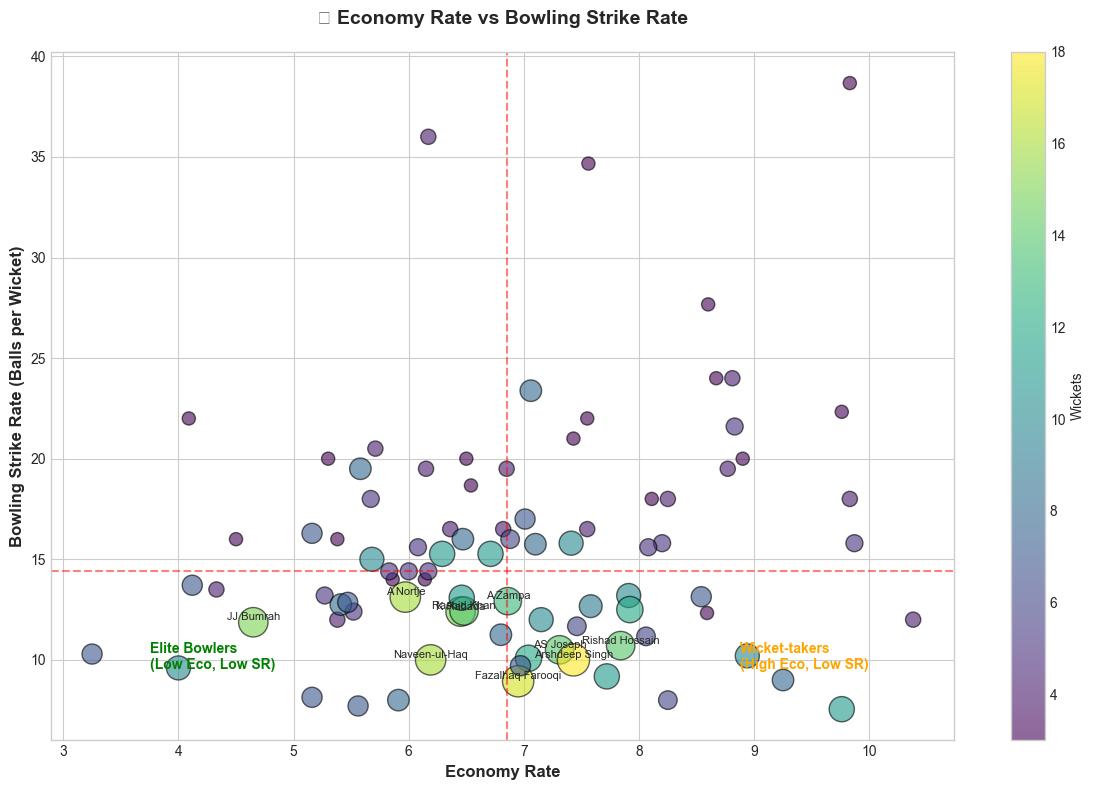


📊 Best Bowling Strike Rates (min 3 wickets):


,bowler,wickets,bowling_sr,economy_rate,bowling_average
37,CJ Jordan,11,7.55,9.76,12.27
53,Gulbadin Naib,7,7.71,5.56,7.14
103,Mehran Khan,6,8.00,8.25,11.00
111,N Thushara,8,8.00,5.91,7.88
45,DS Airee,7,8.14,5.16,7.00
48,Fazalhaq Farooqi,17,8.94,6.95,10.35
127,R Trumpelmann,8,9.00,9.25,13.88
152,T Shamsi,11,9.18,7.72,11.82
153,TA Boult,10,9.60,4.00,6.40
123,PWH de Silva,7,9.71,6.97,11.29


In [26]:
# Scatter plot: Economy Rate vs Bowling Strike Rate
sr_qualified = bowling_stats[(bowling_stats['wickets'] >= 3) & (bowling_stats['legal_balls'] >= 18)].copy()
sr_qualified = sr_qualified[sr_qualified['bowling_sr'].notna()]

fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(sr_qualified['economy_rate'], sr_qualified['bowling_sr'], 
                     s=sr_qualified['wickets'] * 30, alpha=0.6,
                     c=sr_qualified['wickets'], cmap='viridis', edgecolors='black')

# Add labels for top performers
top_performers = sr_qualified.nlargest(10, 'wickets')
for _, row in top_performers.iterrows():
    ax.annotate(row['bowler'], (row['economy_rate'], row['bowling_sr']), 
                fontsize=8, ha='center', va='bottom')

# Add quadrant lines
ax.axhline(sr_qualified['bowling_sr'].median(), color='red', linestyle='--', alpha=0.5)
ax.axvline(sr_qualified['economy_rate'].median(), color='red', linestyle='--', alpha=0.5)

# Quadrant labels
ax.text(sr_qualified['economy_rate'].min() + 0.5, sr_qualified['bowling_sr'].min() + 2, 
        'Elite Bowlers\n(Low Eco, Low SR)', fontsize=10, color='green', fontweight='bold')
ax.text(sr_qualified['economy_rate'].max() - 1.5, sr_qualified['bowling_sr'].min() + 2, 
        'Wicket-takers\n(High Eco, Low SR)', fontsize=10, color='orange', fontweight='bold')

ax.set_xlabel('Economy Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('Bowling Strike Rate (Balls per Wicket)', fontsize=12, fontweight='bold')
ax.set_title('🎯 Economy Rate vs Bowling Strike Rate', fontsize=14, fontweight='bold', pad=20)
plt.colorbar(scatter, label='Wickets')
plt.tight_layout()
plt.show()

print("\n📊 Best Bowling Strike Rates (min 3 wickets):")
display(sr_qualified.nsmallest(10, 'bowling_sr')[['bowler', 'wickets', 'bowling_sr', 'economy_rate', 'bowling_average']])

---
## 🎯 Bowling Effectiveness & Control

## 23. Dot Ball Percentage Analysis

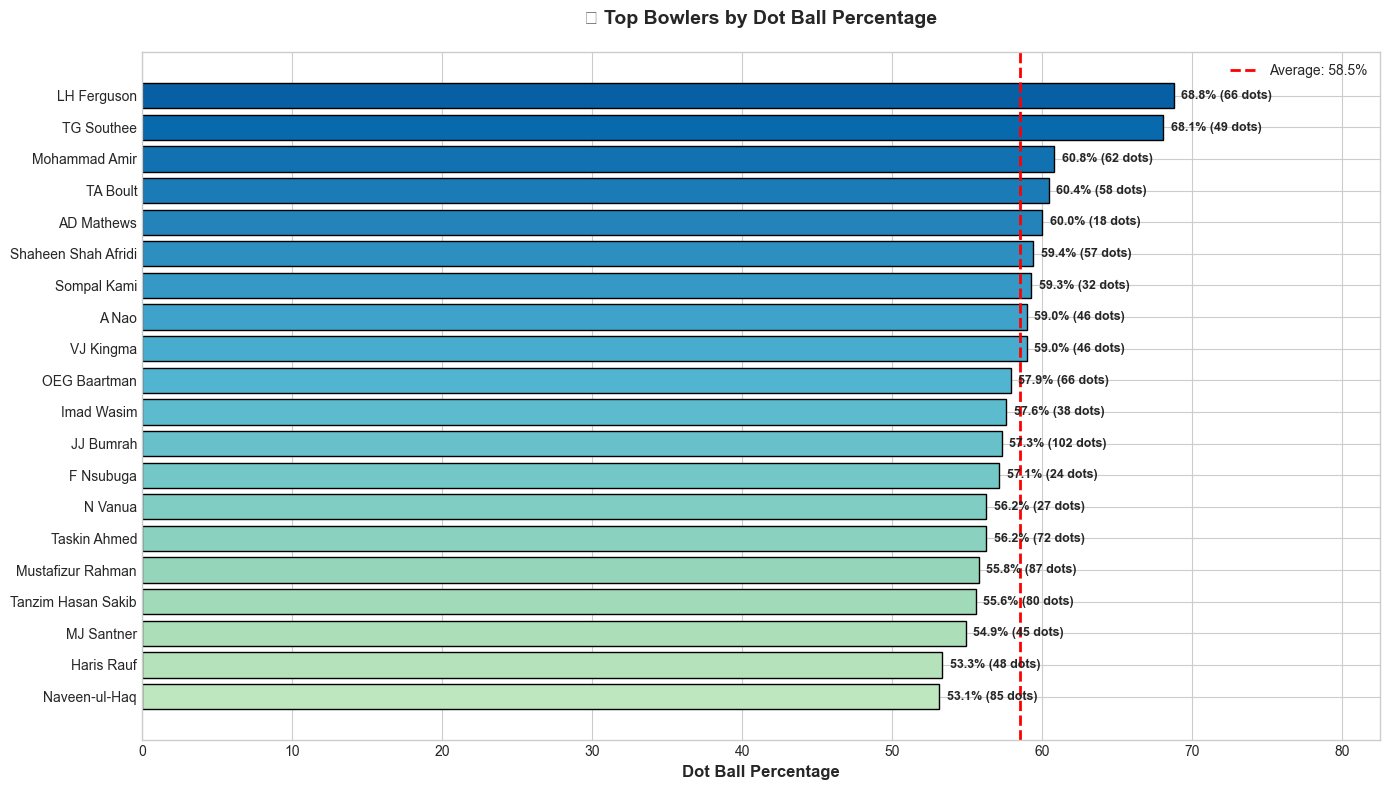


📊 Dot Ball Analysis (min 30 balls):


,bowler,legal_balls,dot_balls,dot_ball_pct,economy_rate
83,LH Ferguson,96,66,68.75,4.12
154,TG Southee,72,49,68.06,3.25
105,Mohammad Amir,102,62,60.78,5.41
153,TA Boult,96,58,60.42,4.00
7,AD Mathews,30,18,60.00,7.20
147,Shaheen Shah Afridi,96,57,59.38,6.88
150,Sompal Kami,54,32,59.26,4.33
2,A Nao,78,46,58.97,6.08
158,VJ Kingma,78,46,58.97,6.15
120,OEG Baartman,114,66,57.89,5.16


In [27]:
# Dot ball analysis for qualified bowlers (min 30 balls)
dot_qualified = bowling_stats[bowling_stats['legal_balls'] >= 30].copy()
dot_qualified = dot_qualified.sort_values('dot_ball_pct', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(14, 8))
colors = plt.cm.GnBu(np.linspace(0.3, 0.9, 20))[::-1]
bars = ax.barh(dot_qualified['bowler'], dot_qualified['dot_ball_pct'], color=colors, edgecolor='black')

# Add value labels
for bar, pct, dots in zip(bars, dot_qualified['dot_ball_pct'], dot_qualified['dot_balls']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
            f'{pct:.1f}% ({int(dots)} dots)', va='center', fontsize=9, fontweight='bold')

ax.axvline(dot_qualified['dot_ball_pct'].mean(), color='red', linestyle='--', linewidth=2, 
           label=f"Average: {dot_qualified['dot_ball_pct'].mean():.1f}%")
ax.set_xlabel('Dot Ball Percentage', fontsize=12, fontweight='bold')
ax.set_title('⭕ Top Bowlers by Dot Ball Percentage', fontsize=14, fontweight='bold', pad=20)
ax.invert_yaxis()
ax.legend()
ax.set_xlim(0, max(dot_qualified['dot_ball_pct']) * 1.2)
plt.tight_layout()
plt.show()

print("\n📊 Dot Ball Analysis (min 30 balls):")
display(dot_qualified[['bowler', 'legal_balls', 'dot_balls', 'dot_ball_pct', 'economy_rate']].head(15))

## 24. Boundaries Conceded Analysis (Fours and Sixes Given)

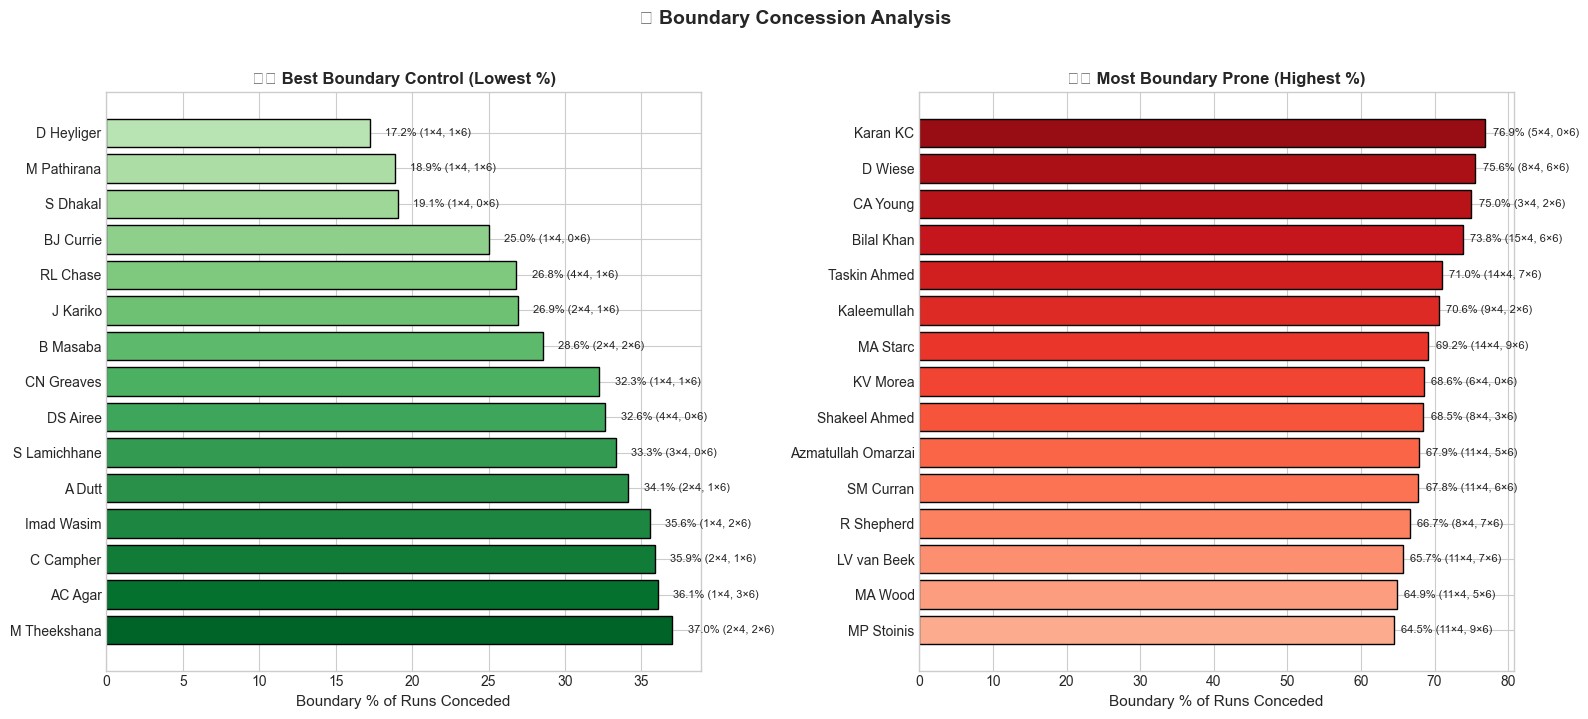

In [28]:
# Boundaries conceded analysis
boundary_conceded = bowling_stats[bowling_stats['legal_balls'] >= 24].copy()
boundary_conceded['total_boundaries'] = boundary_conceded['fours_conceded'] + boundary_conceded['sixes_conceded']
boundary_conceded['boundary_runs_conceded'] = boundary_conceded['fours_conceded'] * 4 + boundary_conceded['sixes_conceded'] * 6
boundary_conceded['boundary_pct_of_runs'] = (boundary_conceded['boundary_runs_conceded'] / boundary_conceded['runs_conceded'] * 100).round(2)

# Best and worst boundary concession
best_boundary = boundary_conceded.nsmallest(15, 'boundary_pct_of_runs')
worst_boundary = boundary_conceded.nlargest(15, 'boundary_pct_of_runs')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Best (least boundaries conceded)
colors1 = plt.cm.Greens(np.linspace(0.3, 0.9, 15))
axes[0].barh(best_boundary['bowler'], best_boundary['boundary_pct_of_runs'], color=colors1, edgecolor='black')
axes[0].set_xlabel('Boundary % of Runs Conceded', fontsize=11)
axes[0].set_title('🛡️ Best Boundary Control (Lowest %)', fontsize=12, fontweight='bold')
axes[0].invert_yaxis()
for i, (pct, f, s) in enumerate(zip(best_boundary['boundary_pct_of_runs'], 
                                     best_boundary['fours_conceded'], best_boundary['sixes_conceded'])):
    axes[0].text(pct + 1, i, f'{pct:.1f}% ({int(f)}×4, {int(s)}×6)', va='center', fontsize=8)

# Worst (most boundaries conceded)
colors2 = plt.cm.Reds(np.linspace(0.3, 0.9, 15))[::-1]
axes[1].barh(worst_boundary['bowler'], worst_boundary['boundary_pct_of_runs'], color=colors2, edgecolor='black')
axes[1].set_xlabel('Boundary % of Runs Conceded', fontsize=11)
axes[1].set_title('⚠️ Most Boundary Prone (Highest %)', fontsize=12, fontweight='bold')
axes[1].invert_yaxis()
for i, (pct, f, s) in enumerate(zip(worst_boundary['boundary_pct_of_runs'], 
                                     worst_boundary['fours_conceded'], worst_boundary['sixes_conceded'])):
    axes[1].text(pct + 1, i, f'{pct:.1f}% ({int(f)}×4, {int(s)}×6)', va='center', fontsize=8)

plt.suptitle('📊 Boundary Concession Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 25. Wickets Distribution Across Overs (Powerplay, Middle, Death)

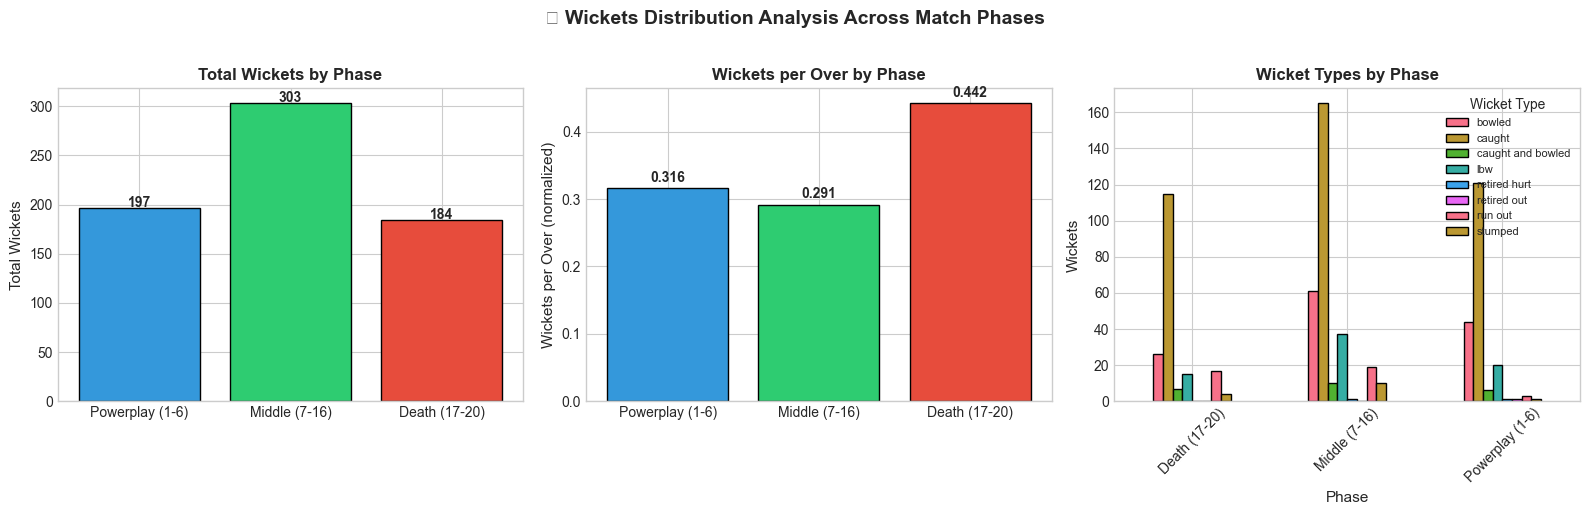


📊 Phase-wise Wicket Summary:


,phase,wickets,wickets_per_over
2,Powerplay (1-6),197,0.316
1,Middle (7-16),303,0.291
0,Death (17-20),184,0.442


In [29]:
# Analyze wickets by phase
wickets_df = deliveries[deliveries['wicket_type'].notna()].copy()

# Phase-wise wicket distribution
phase_wickets = wickets_df.groupby('phase').size().reset_index(name='wickets')
phase_wickets['phase_order'] = phase_wickets['phase'].map({'Powerplay (1-6)': 1, 'Middle (7-16)': 2, 'Death (17-20)': 3})
phase_wickets = phase_wickets.sort_values('phase_order')

# Calculate overs in each phase for fair comparison
phase_overs = {'Powerplay (1-6)': 6, 'Middle (7-16)': 10, 'Death (17-20)': 4}
total_matches = deliveries['match_id'].nunique()
phase_wickets['wickets_per_over'] = phase_wickets.apply(
    lambda x: x['wickets'] / (phase_overs[x['phase']] * total_matches * 2), axis=1
).round(3)

# Top wicket-takers by phase
bowler_phase_wickets = wickets_df.groupby(['bowler', 'phase']).size().unstack(fill_value=0)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Total wickets by phase
colors = ['#3498db', '#2ecc71', '#e74c3c']
axes[0].bar(phase_wickets['phase'], phase_wickets['wickets'], color=colors, edgecolor='black')
axes[0].set_ylabel('Total Wickets', fontsize=11)
axes[0].set_title('Total Wickets by Phase', fontsize=12, fontweight='bold')
for i, v in enumerate(phase_wickets['wickets']):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# Wickets per over by phase
axes[1].bar(phase_wickets['phase'], phase_wickets['wickets_per_over'], color=colors, edgecolor='black')
axes[1].set_ylabel('Wickets per Over (normalized)', fontsize=11)
axes[1].set_title('Wickets per Over by Phase', fontsize=12, fontweight='bold')
for i, v in enumerate(phase_wickets['wickets_per_over']):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

# Wicket type distribution by phase
wicket_type_phase = wickets_df.groupby(['phase', 'wicket_type']).size().unstack(fill_value=0)
wicket_type_phase.plot(kind='bar', ax=axes[2], edgecolor='black')
axes[2].set_xlabel('Phase', fontsize=11)
axes[2].set_ylabel('Wickets', fontsize=11)
axes[2].set_title('Wicket Types by Phase', fontsize=12, fontweight='bold')
axes[2].legend(title='Wicket Type', loc='upper right', fontsize=8)
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle('🎯 Wickets Distribution Analysis Across Match Phases', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n📊 Phase-wise Wicket Summary:")
display(phase_wickets[['phase', 'wickets', 'wickets_per_over']])

## 26. Bowling Performance in Winning vs Losing Matches

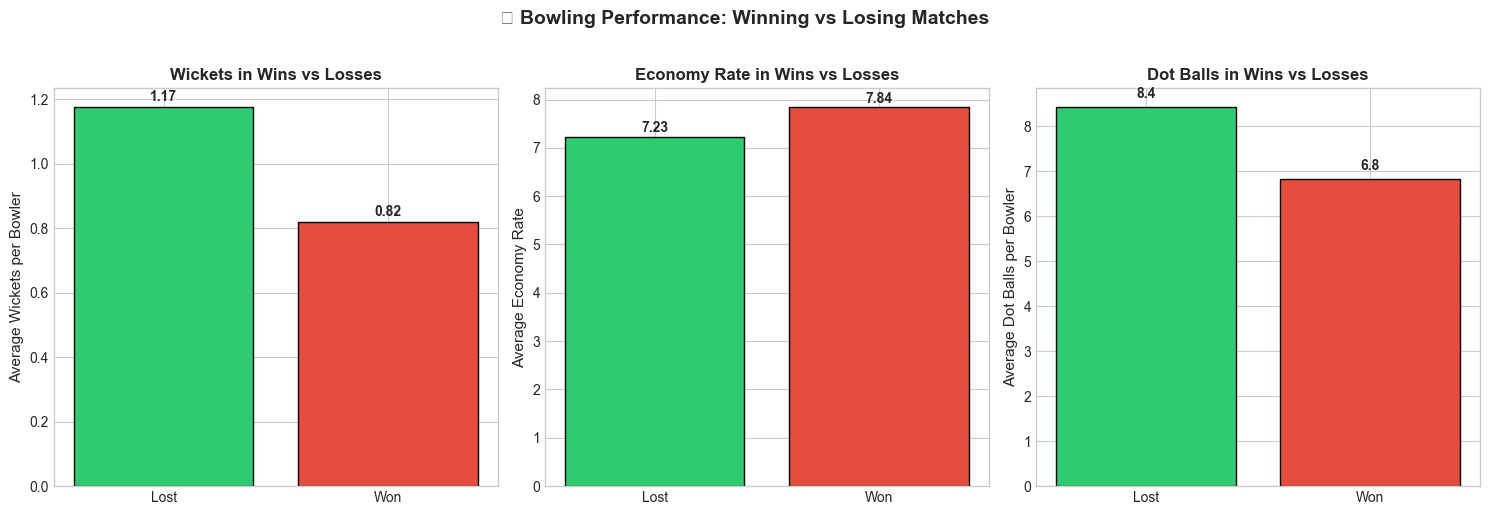


📊 Bowling Stats in Wins vs Losses:


,runs_conceded,wickets,economy,dots
result,,,,
Lost,22.08,1.17,7.23,8.42
Won,20.82,0.82,7.84,6.82


In [30]:
# Merge bowling data with match results
bowling_innings = deliveries.groupby(['match_id', 'bowling_team', 'bowler']).agg({
    'total_runs': 'sum',
    'ball': 'count',
    'is_dot': 'sum',
    'wicket_type': lambda x: x.notna().sum()
}).reset_index()
bowling_innings.columns = ['match_id', 'team', 'bowler', 'runs_conceded', 'balls', 'dots', 'wickets']

# Merge with match results
bowling_with_results = bowling_innings.merge(match_results, left_on='match_id', right_on='match_number', how='left')
bowling_with_results['result'] = bowling_with_results.apply(
    lambda x: 'Won' if x['team'] == x['winner'] else ('Lost' if pd.notna(x['winner']) else 'No Result'), axis=1
)

# Filter out No Results
bowl_wl = bowling_with_results[bowling_with_results['result'].isin(['Won', 'Lost'])]
bowl_wl['economy'] = (bowl_wl['runs_conceded'] / (bowl_wl['balls'] / 6)).round(2)

# Overall comparison
bowl_wl_summary = bowl_wl.groupby('result').agg({
    'runs_conceded': 'mean',
    'wickets': 'mean',
    'economy': 'mean',
    'dots': 'mean'
}).round(2)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['#2ecc71', '#e74c3c']

# Average wickets per bowler
wl_wickets = bowl_wl.groupby('result')['wickets'].mean()
axes[0].bar(wl_wickets.index, wl_wickets.values, color=colors, edgecolor='black')
axes[0].set_ylabel('Average Wickets per Bowler', fontsize=11)
axes[0].set_title('Wickets in Wins vs Losses', fontsize=12, fontweight='bold')
for i, v in enumerate(wl_wickets.values):
    axes[0].text(i, v + 0.02, f'{v:.2f}', ha='center', fontweight='bold')

# Economy rate
wl_eco = bowl_wl.groupby('result')['economy'].mean()
axes[1].bar(wl_eco.index, wl_eco.values, color=colors, edgecolor='black')
axes[1].set_ylabel('Average Economy Rate', fontsize=11)
axes[1].set_title('Economy Rate in Wins vs Losses', fontsize=12, fontweight='bold')
for i, v in enumerate(wl_eco.values):
    axes[1].text(i, v + 0.1, f'{v:.2f}', ha='center', fontweight='bold')

# Dot balls
wl_dots = bowl_wl.groupby('result')['dots'].mean()
axes[2].bar(wl_dots.index, wl_dots.values, color=colors, edgecolor='black')
axes[2].set_ylabel('Average Dot Balls per Bowler', fontsize=11)
axes[2].set_title('Dot Balls in Wins vs Losses', fontsize=12, fontweight='bold')
for i, v in enumerate(wl_dots.values):
    axes[2].text(i, v + 0.2, f'{v:.1f}', ha='center', fontweight='bold')

plt.suptitle('🎯 Bowling Performance: Winning vs Losing Matches', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n📊 Bowling Stats in Wins vs Losses:")
display(bowl_wl_summary)

## 27. Team-wise Economy Rate Comparison

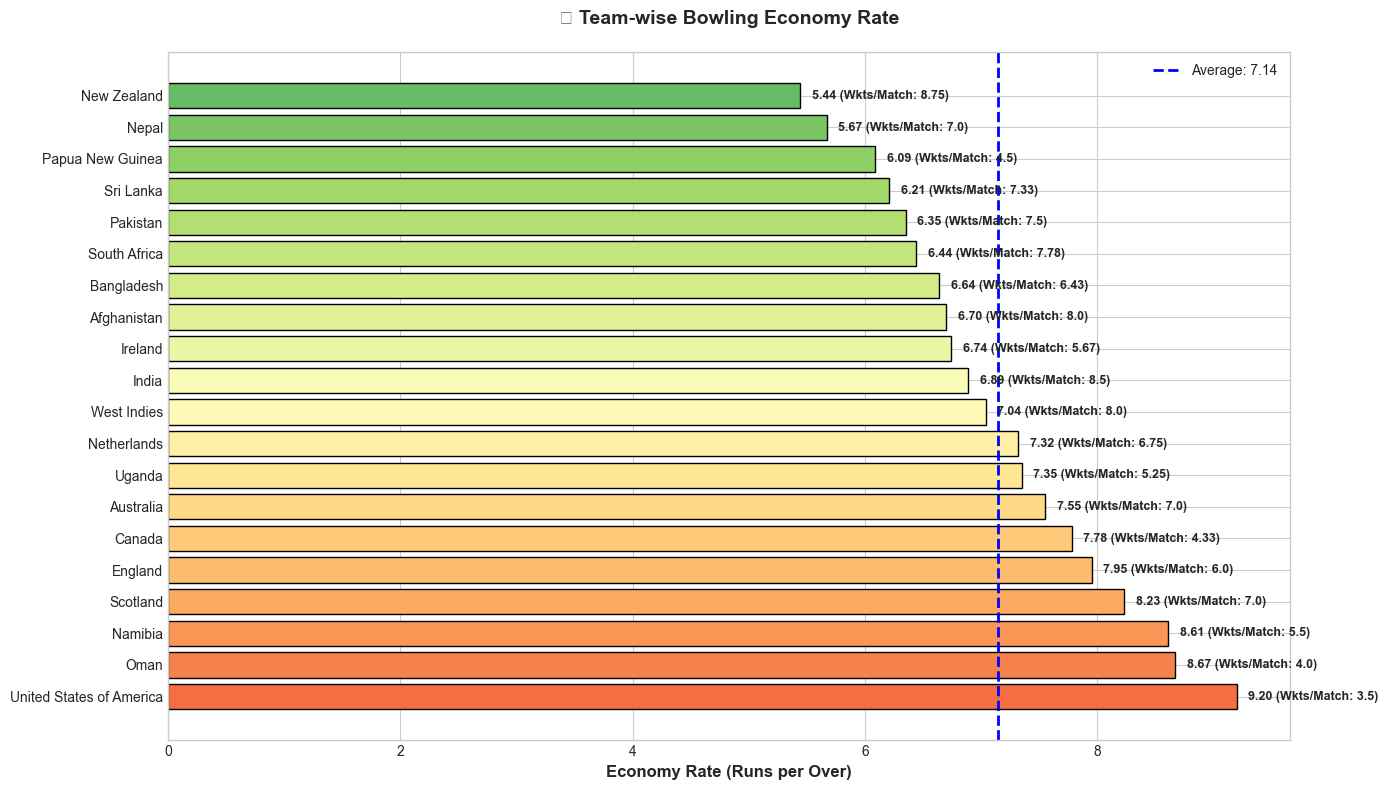


📊 Team Bowling Summary:


,team,matches,wickets,runs_conceded,economy_rate,dot_ball_pct,wickets_per_match
10,New Zealand,4,35,426,5.44,56.17,8.75
8,Nepal,3,21,330,5.67,45.27,7.00
13,Papua New Guinea,4,18,395,6.09,49.10,4.50
16,Sri Lanka,3,22,323,6.21,45.83,7.33
12,Pakistan,4,30,508,6.35,53.54,7.50
15,South Africa,9,70,1102,6.44,47.08,7.78
2,Bangladesh,7,45,867,6.64,49.74,6.43
0,Afghanistan,8,64,919,6.70,48.24,8.00
6,Ireland,3,17,345,6.74,47.23,5.67
5,India,8,68,1052,6.89,45.96,8.50


In [31]:
# Team-wise bowling statistics
team_bowling = deliveries.groupby('bowling_team').agg({
    'total_runs': 'sum',
    'ball': 'count',
    'is_dot': 'sum',
    'wicket_type': lambda x: x.notna().sum(),
    'is_four': 'sum',
    'is_six': 'sum',
    'match_id': 'nunique'
}).reset_index()

team_bowling.columns = ['team', 'runs_conceded', 'balls', 'dot_balls', 'wickets', 
                        'fours_given', 'sixes_given', 'matches']

# Calculate legal balls
legal_balls = deliveries[deliveries['is_legal']].groupby('bowling_team').size().reset_index(name='legal_balls')
team_bowling = team_bowling.merge(legal_balls, left_on='team', right_on='bowling_team', how='left')

team_bowling['economy_rate'] = (team_bowling['runs_conceded'] / (team_bowling['legal_balls'] / 6)).round(2)
team_bowling['dot_ball_pct'] = (team_bowling['dot_balls'] / team_bowling['legal_balls'] * 100).round(2)
team_bowling['wickets_per_match'] = (team_bowling['wickets'] / team_bowling['matches']).round(2)

team_bowling = team_bowling.sort_values('economy_rate')

# Create visualization
fig, ax = plt.subplots(figsize=(14, 8))

colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(team_bowling)))
bars = ax.barh(team_bowling['team'], team_bowling['economy_rate'], color=colors, edgecolor='black')

ax.axvline(team_bowling['economy_rate'].mean(), color='blue', linestyle='--', linewidth=2, 
           label=f"Average: {team_bowling['economy_rate'].mean():.2f}")

ax.set_xlabel('Economy Rate (Runs per Over)', fontsize=12, fontweight='bold')
ax.set_title('🎯 Team-wise Bowling Economy Rate', fontsize=14, fontweight='bold', pad=20)
ax.invert_yaxis()
ax.legend()

# Add value labels
for bar, eco, wkts in zip(bars, team_bowling['economy_rate'], team_bowling['wickets_per_match']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, 
            f'{eco:.2f} (Wkts/Match: {wkts})', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📊 Team Bowling Summary:")
display(team_bowling[['team', 'matches', 'wickets', 'runs_conceded', 'economy_rate', 
                      'dot_ball_pct', 'wickets_per_match']].drop('bowling_team', axis=1, errors='ignore'))

## 28. Total Wickets Taken by Each Team

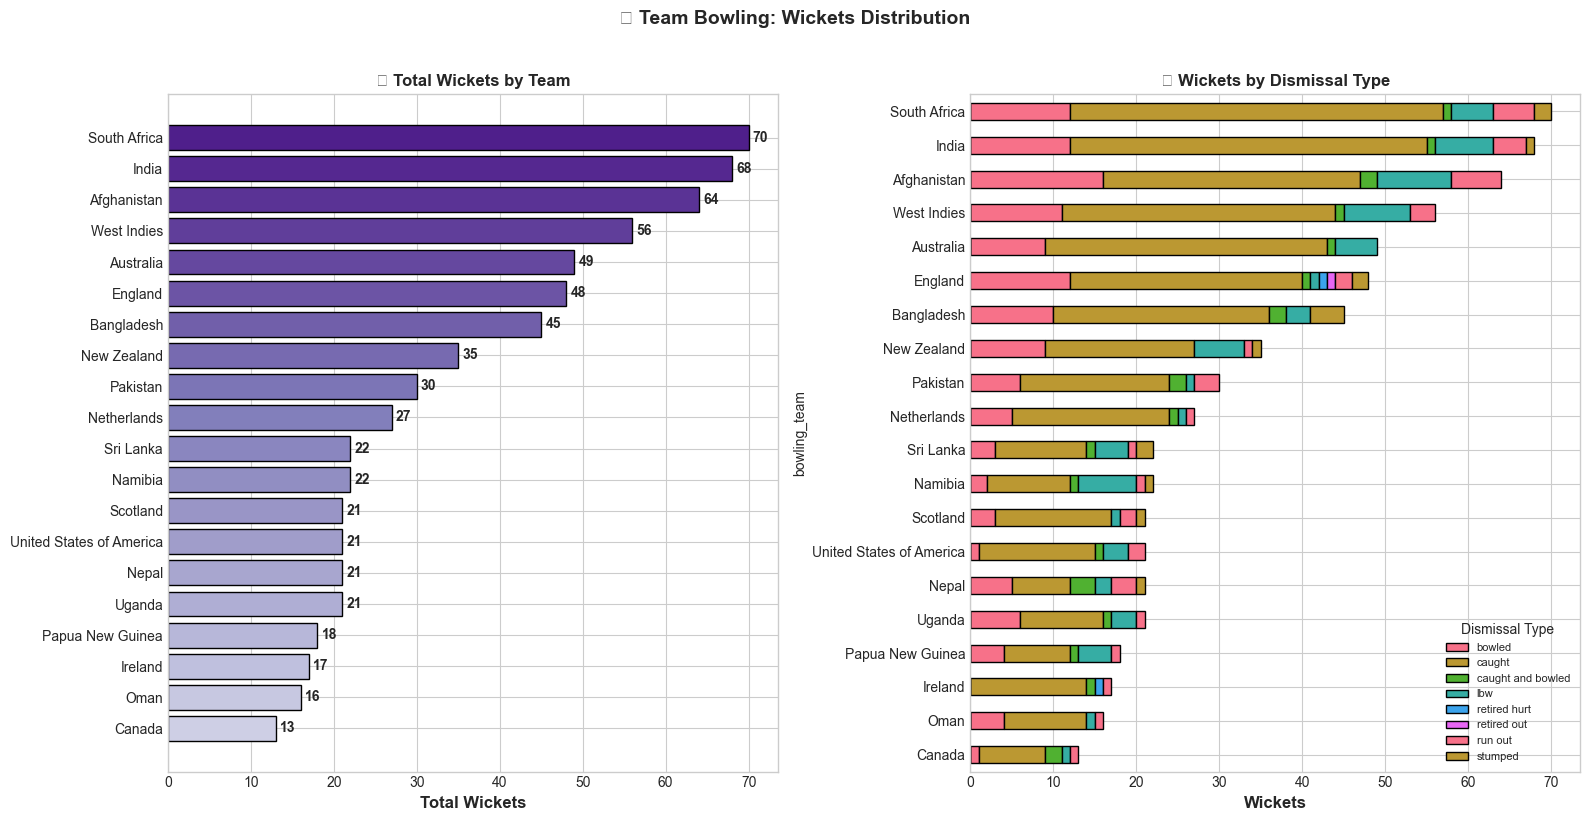


📊 Overall Dismissal Type Distribution:
wicket_type
caught               401
bowled               131
lbw                   72
run out               39
caught and bowled     23
stumped               15
retired hurt           2
retired out            1
Name: count, dtype: int64


In [32]:
# Team wickets by dismissal type
team_wickets = wickets_df.groupby(['bowling_team', 'wicket_type']).size().unstack(fill_value=0)
team_wickets['Total'] = team_wickets.sum(axis=1)
team_wickets = team_wickets.sort_values('Total', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Total wickets bar chart
colors = plt.cm.Purples(np.linspace(0.3, 0.9, len(team_wickets)))
axes[0].barh(team_wickets.index, team_wickets['Total'], color=colors, edgecolor='black')
axes[0].set_xlabel('Total Wickets', fontsize=12, fontweight='bold')
axes[0].set_title('🎯 Total Wickets by Team', fontsize=12, fontweight='bold')

for i, v in enumerate(team_wickets['Total']):
    axes[0].text(v + 0.5, i, str(v), va='center', fontweight='bold')

# Stacked bar chart by dismissal type
wicket_types = [col for col in team_wickets.columns if col != 'Total']
team_wickets[wicket_types].plot(kind='barh', stacked=True, ax=axes[1], edgecolor='black')
axes[1].set_xlabel('Wickets', fontsize=12, fontweight='bold')
axes[1].set_title('🎯 Wickets by Dismissal Type', fontsize=12, fontweight='bold')
axes[1].legend(title='Dismissal Type', loc='lower right', fontsize=8)

plt.suptitle('📊 Team Bowling: Wickets Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Most common dismissal types overall
print("\n📊 Overall Dismissal Type Distribution:")
print(wickets_df['wicket_type'].value_counts())

---
# ⚖️ PART 3: COMBINED BATTING vs BOWLING INSIGHTS
---

## 29. Team Batting Strength vs Bowling Strength Comparison

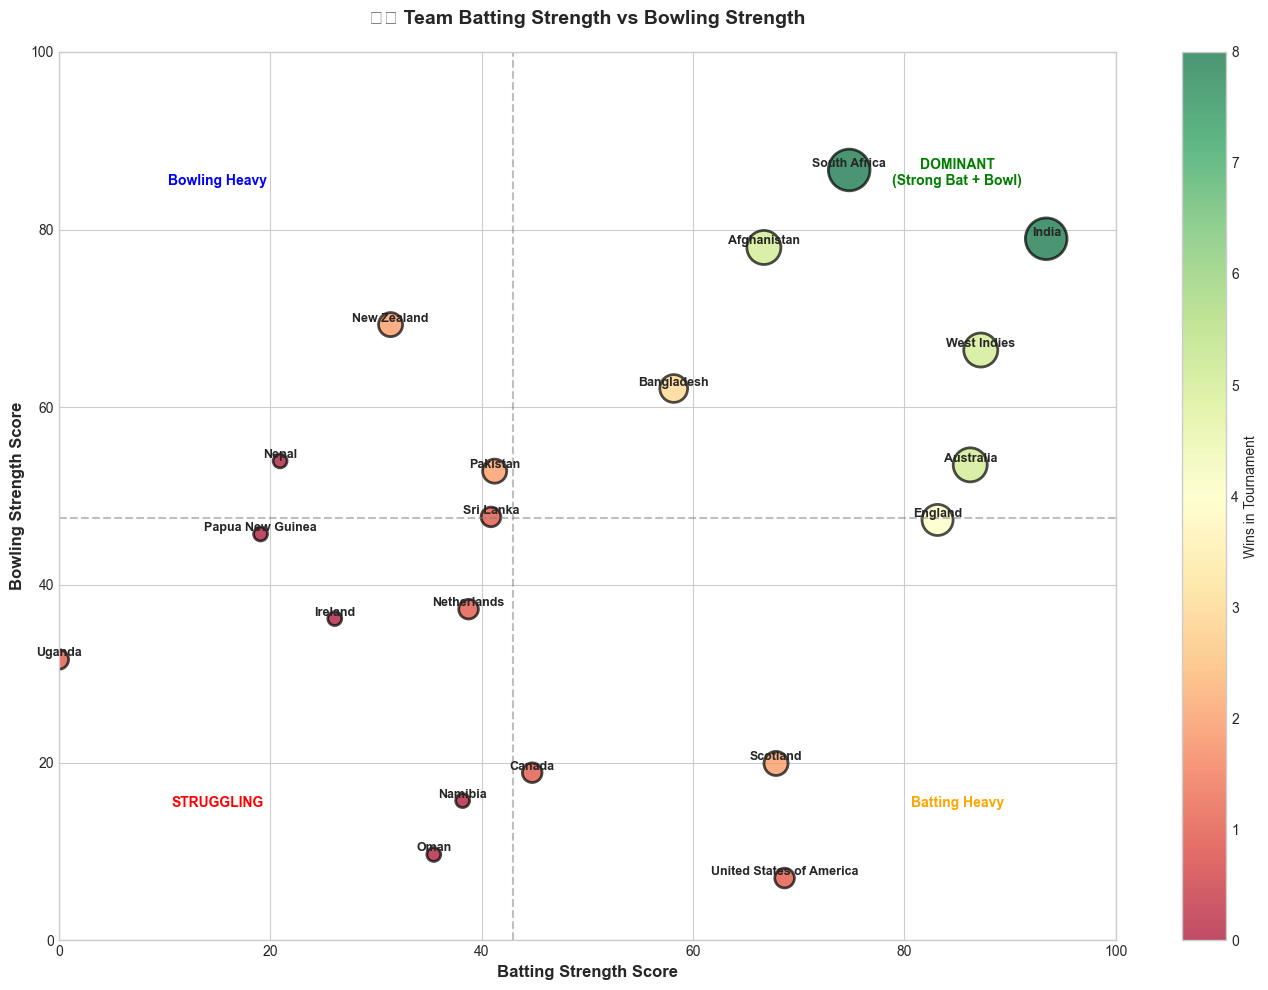


📊 Team Combined Strength Analysis:


,team,bat_score,bowl_score,wins,bat_runs,bat_sr,bowl_wickets,bowl_economy
0,India,93.42,78.96,8.0,1201,133.74,68,6.89
1,South Africa,74.78,86.70,8.0,1058,110.09,70,6.44
2,West Indies,87.23,66.44,5.0,1056,135.56,56,7.04
3,Australia,86.23,53.52,5.0,981,140.95,49,7.55
4,Afghanistan,66.71,77.98,5.0,922,107.21,64,6.70
5,England,83.14,47.32,4.0,856,147.08,48,7.95
7,Bangladesh,58.18,62.11,3.0,819,100.12,45,6.64
16,New Zealand,31.39,69.30,2.0,307,96.54,35,5.44
8,Scotland,67.86,19.92,2.0,544,147.03,21,8.23
9,Pakistan,41.24,52.81,2.0,467,100.65,30,6.35


In [33]:
# Combine team batting and bowling stats
team_combined = team_batting[['team', 'total_runs', 'strike_rate', 'fours', 'sixes', 'matches']].copy()
team_combined.columns = ['team', 'bat_runs', 'bat_sr', 'bat_fours', 'bat_sixes', 'matches']

bowl_cols = team_bowling[['team', 'wickets', 'economy_rate', 'dot_ball_pct']].copy()
bowl_cols.columns = ['team', 'bowl_wickets', 'bowl_economy', 'bowl_dot_pct']

team_combined = team_combined.merge(bowl_cols, on='team', how='outer')

# Normalize metrics for comparison (0-100 scale)
team_combined['bat_score'] = ((team_combined['bat_runs'] - team_combined['bat_runs'].min()) / 
                               (team_combined['bat_runs'].max() - team_combined['bat_runs'].min()) * 50 +
                              (team_combined['bat_sr'] - team_combined['bat_sr'].min()) / 
                               (team_combined['bat_sr'].max() - team_combined['bat_sr'].min()) * 50).round(2)

team_combined['bowl_score'] = ((team_combined['bowl_wickets'] - team_combined['bowl_wickets'].min()) / 
                                (team_combined['bowl_wickets'].max() - team_combined['bowl_wickets'].min()) * 50 +
                               (team_combined['bowl_economy'].max() - team_combined['bowl_economy']) / 
                                (team_combined['bowl_economy'].max() - team_combined['bowl_economy'].min()) * 50).round(2)

# Create scatter plot
fig, ax = plt.subplots(figsize=(14, 10))

# Get team wins for color coding
team_wins = matches[matches['winner'].notna()].groupby('winner').size().reset_index(name='wins')
team_combined = team_combined.merge(team_wins, left_on='team', right_on='winner', how='left')
team_combined['wins'] = team_combined['wins'].fillna(0)

scatter = ax.scatter(team_combined['bat_score'], team_combined['bowl_score'], 
                     s=team_combined['wins'] * 100 + 100, alpha=0.7,
                     c=team_combined['wins'], cmap='RdYlGn', edgecolors='black', linewidth=2)

# Add team labels
for _, row in team_combined.iterrows():
    ax.annotate(row['team'], (row['bat_score'], row['bowl_score']), 
                fontsize=9, ha='center', va='bottom', fontweight='bold')

# Add quadrant lines
ax.axhline(team_combined['bowl_score'].median(), color='gray', linestyle='--', alpha=0.5)
ax.axvline(team_combined['bat_score'].median(), color='gray', linestyle='--', alpha=0.5)

# Quadrant labels
ax.text(85, 85, 'DOMINANT\n(Strong Bat + Bowl)', fontsize=10, ha='center', color='green', fontweight='bold')
ax.text(15, 85, 'Bowling Heavy', fontsize=10, ha='center', color='blue', fontweight='bold')
ax.text(85, 15, 'Batting Heavy', fontsize=10, ha='center', color='orange', fontweight='bold')
ax.text(15, 15, 'STRUGGLING', fontsize=10, ha='center', color='red', fontweight='bold')

ax.set_xlabel('Batting Strength Score', fontsize=12, fontweight='bold')
ax.set_ylabel('Bowling Strength Score', fontsize=12, fontweight='bold')
ax.set_title('⚖️ Team Batting Strength vs Bowling Strength', fontsize=14, fontweight='bold', pad=20)
plt.colorbar(scatter, label='Wins in Tournament')
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

print("\n📊 Team Combined Strength Analysis:")
display(team_combined[['team', 'bat_score', 'bowl_score', 'wins', 'bat_runs', 'bat_sr', 
                       'bowl_wickets', 'bowl_economy']].sort_values('wins', ascending=False))

## 30. Match Outcomes Based on Batting and Bowling Balance

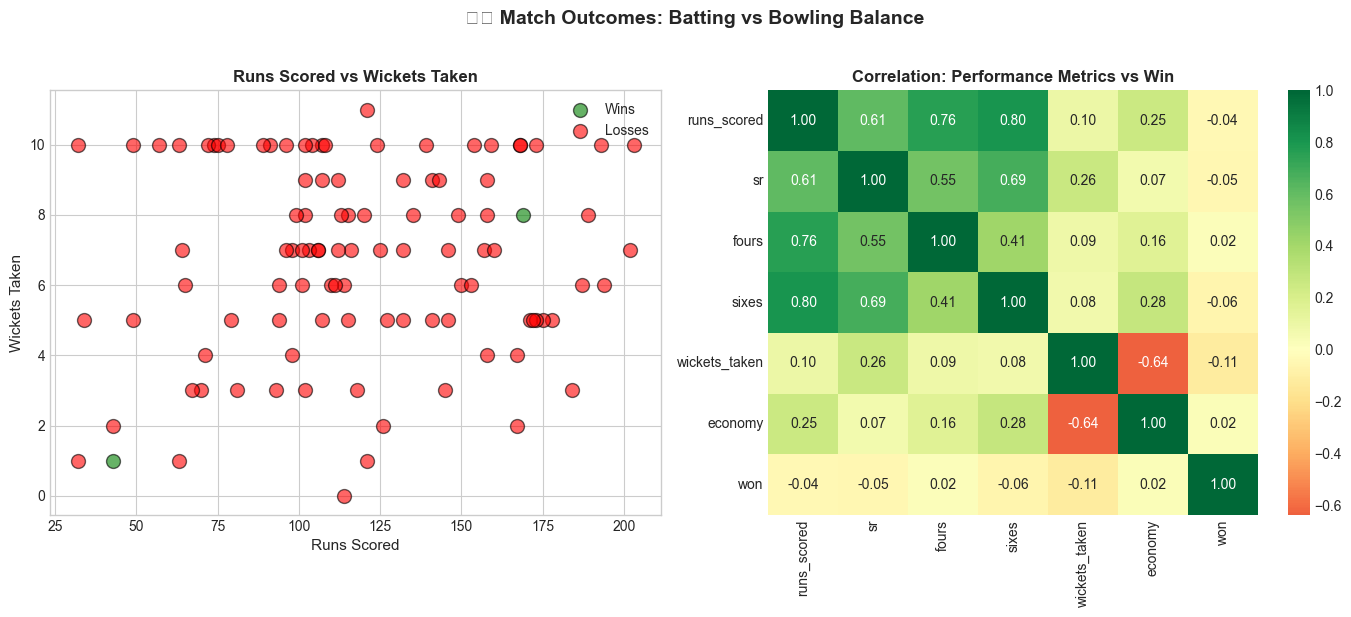


📊 Key Winning Factors - Correlation with Win:
won            1.000000
economy        0.023011
fours          0.021199
runs_scored   -0.043207
sr            -0.052747
sixes         -0.062508
Name: won, dtype: float64


In [34]:
# Analyze match-level performance
match_batting = deliveries.groupby(['match_id', 'batting_team']).agg({
    'runs_off_bat': 'sum',
    'ball': 'count',
    'is_four': 'sum',
    'is_six': 'sum'
}).reset_index()
match_batting.columns = ['match_id', 'team', 'runs_scored', 'balls_faced', 'fours', 'sixes']
match_batting['sr'] = (match_batting['runs_scored'] / match_batting['balls_faced'] * 100).round(2)

match_bowling = deliveries.groupby(['match_id', 'bowling_team']).agg({
    'total_runs': 'sum',
    'wicket_type': lambda x: x.notna().sum(),
    'ball': 'count'
}).reset_index()
match_bowling.columns = ['match_id', 'team', 'runs_conceded', 'wickets_taken', 'balls']
match_bowling['economy'] = (match_bowling['runs_conceded'] / (match_bowling['balls'] / 6)).round(2)

# Merge with match results
match_perf = match_batting.merge(match_bowling, on=['match_id', 'team'])
match_perf = match_perf.merge(match_results[['match_number', 'winner']], 
                               left_on='match_id', right_on='match_number', how='left')
match_perf['won'] = match_perf['team'] == match_perf['winner']

# Calculate performance balance
match_perf['bat_dominance'] = (match_perf['runs_scored'] - match_perf['runs_scored'].mean()) / match_perf['runs_scored'].std()
match_perf['bowl_dominance'] = (match_perf['wickets_taken'] - match_perf['wickets_taken'].mean()) / match_perf['wickets_taken'].std()

# Analyze wins by balance
winning_matches = match_perf[match_perf['won'] == True]
losing_matches = match_perf[match_perf['won'] == False]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter plot of batting vs bowling performance in wins
ax1 = axes[0]
ax1.scatter(winning_matches['runs_scored'], winning_matches['wickets_taken'], 
            c='green', alpha=0.6, s=100, label='Wins', edgecolors='black')
ax1.scatter(losing_matches['runs_scored'], losing_matches['wickets_taken'], 
            c='red', alpha=0.6, s=100, label='Losses', edgecolors='black')
ax1.set_xlabel('Runs Scored', fontsize=11)
ax1.set_ylabel('Wickets Taken', fontsize=11)
ax1.set_title('Runs Scored vs Wickets Taken', fontsize=12, fontweight='bold')
ax1.legend()

# Heatmap correlation
metrics_df = match_perf[['runs_scored', 'sr', 'fours', 'sixes', 'wickets_taken', 'economy', 'won']].copy()
metrics_df['won'] = metrics_df['won'].astype(int)
correlation = metrics_df.corr()

sns.heatmap(correlation, annot=True, cmap='RdYlGn', center=0, ax=axes[1], fmt='.2f')
axes[1].set_title('Correlation: Performance Metrics vs Win', fontsize=12, fontweight='bold')

plt.suptitle('⚖️ Match Outcomes: Batting vs Bowling Balance', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Key insights
print("\n📊 Key Winning Factors - Correlation with Win:")
print(correlation['won'].sort_values(ascending=False)[:-1])

## 31. Venue Impact on Batting vs Bowling Performance

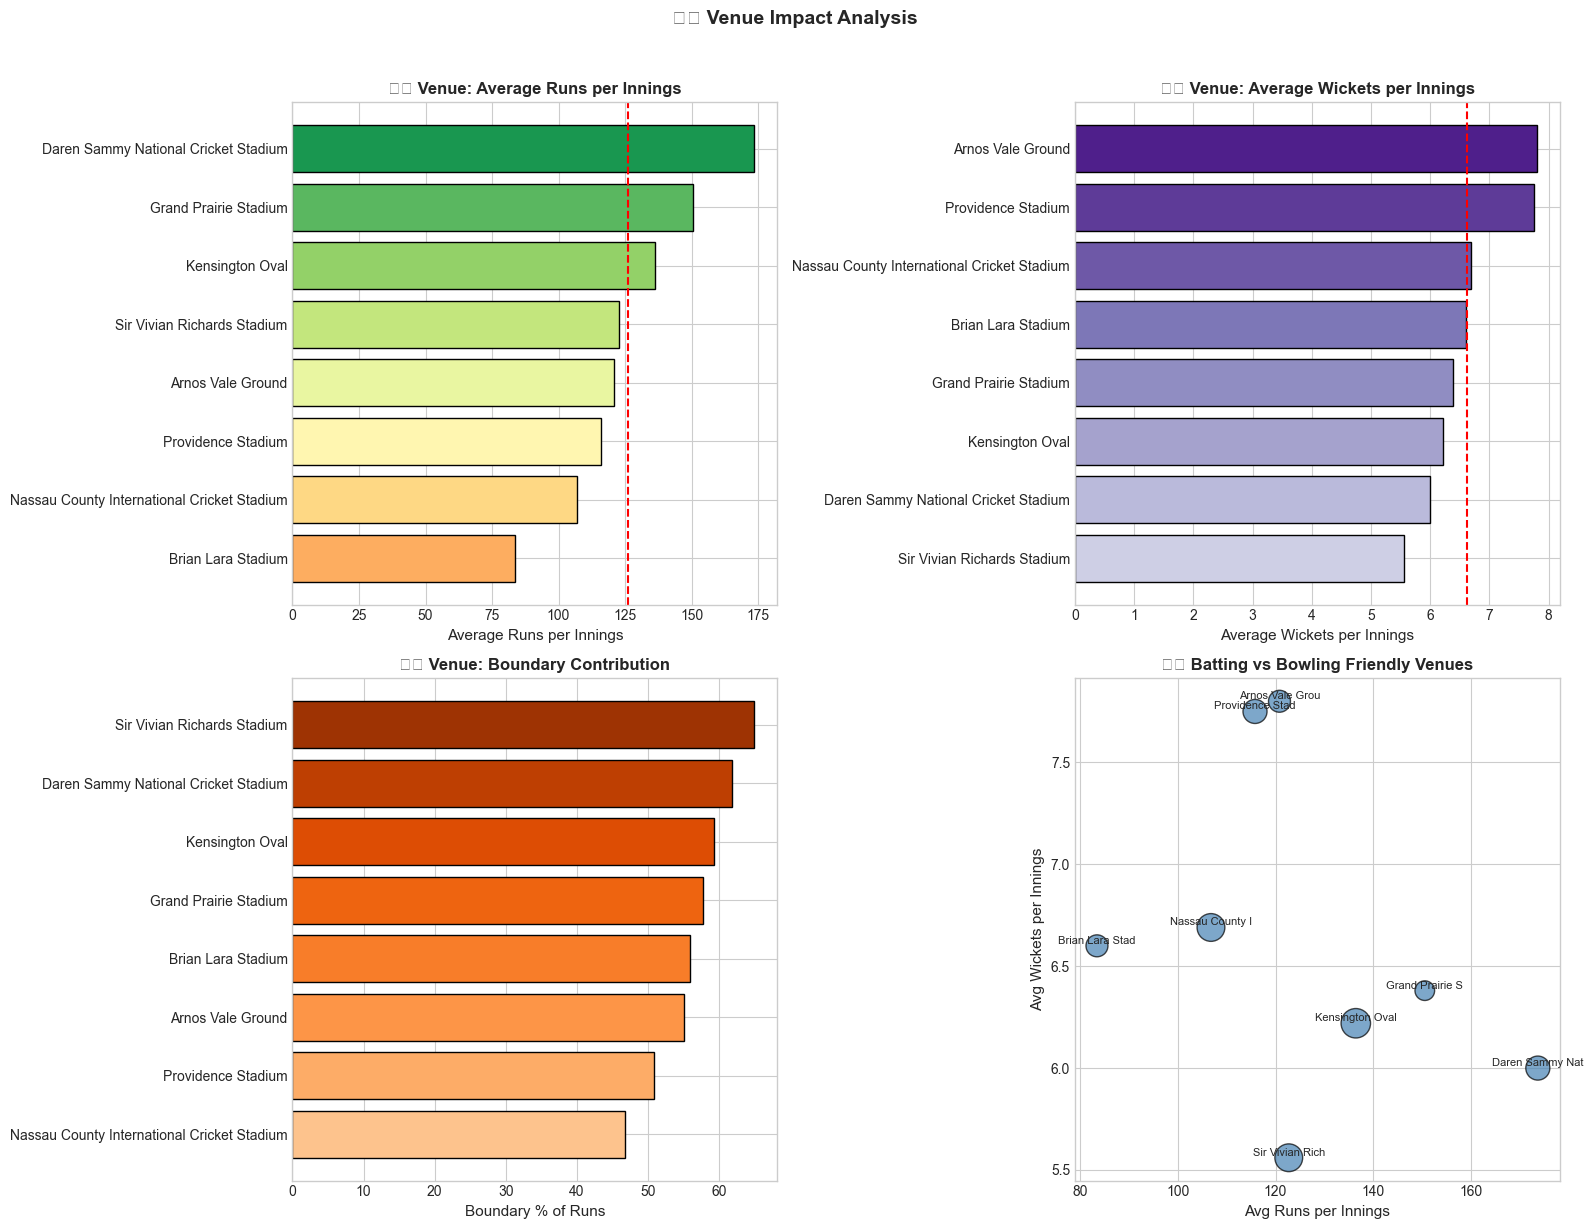


📊 Venue Statistics Summary:


,venue_short,matches,avg_runs_per_innings,avg_wickets_per_innings,boundary_pct
0,Arnos Vale Ground,5,120.8,7.80,55.10
1,Brian Lara Stadium,5,83.5,6.60,55.99
3,Daren Sammy National Cricket Stadium,6,173.6,6.00,61.84
4,Grand Prairie Stadium,4,150.5,6.38,57.76
5,Kensington Oval,9,136.4,6.22,59.37
6,Nassau County International Cricket Stadium,8,106.8,6.69,46.74
7,Providence Stadium,6,115.8,7.75,50.93
8,Sir Vivian Richards Stadium,8,122.7,5.56,64.98


In [35]:
# Venue-wise analysis
venue_stats = deliveries.groupby('venue').agg({
    'runs_off_bat': 'sum',
    'total_runs': 'sum',
    'ball': 'count',
    'is_four': 'sum',
    'is_six': 'sum',
    'wicket_type': lambda x: x.notna().sum(),
    'match_id': 'nunique'
}).reset_index()

venue_stats.columns = ['venue', 'runs_off_bat', 'total_runs', 'balls', 'fours', 'sixes', 'wickets', 'matches']
venue_stats['avg_runs_per_innings'] = (venue_stats['total_runs'] / (venue_stats['matches'] * 2)).round(1)
venue_stats['avg_wickets_per_innings'] = (venue_stats['wickets'] / (venue_stats['matches'] * 2)).round(2)
venue_stats['boundary_pct'] = ((venue_stats['fours'] * 4 + venue_stats['sixes'] * 6) / venue_stats['runs_off_bat'] * 100).round(2)

# Simplify venue names
venue_stats['venue_short'] = venue_stats['venue'].str.split(',').str[0]

# Filter venues with at least 2 matches
venue_stats = venue_stats[venue_stats['matches'] >= 2]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Average runs per innings
ax1 = axes[0, 0]
venue_sorted = venue_stats.sort_values('avg_runs_per_innings', ascending=True)
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(venue_sorted)))
ax1.barh(venue_sorted['venue_short'], venue_sorted['avg_runs_per_innings'], color=colors, edgecolor='black')
ax1.set_xlabel('Average Runs per Innings', fontsize=11)
ax1.set_title('🏟️ Venue: Average Runs per Innings', fontsize=12, fontweight='bold')
ax1.axvline(venue_sorted['avg_runs_per_innings'].mean(), color='red', linestyle='--', label='Average')

# Average wickets per innings
ax2 = axes[0, 1]
venue_sorted_wkt = venue_stats.sort_values('avg_wickets_per_innings', ascending=True)
colors2 = plt.cm.Purples(np.linspace(0.3, 0.9, len(venue_sorted_wkt)))
ax2.barh(venue_sorted_wkt['venue_short'], venue_sorted_wkt['avg_wickets_per_innings'], color=colors2, edgecolor='black')
ax2.set_xlabel('Average Wickets per Innings', fontsize=11)
ax2.set_title('🏟️ Venue: Average Wickets per Innings', fontsize=12, fontweight='bold')
ax2.axvline(venue_sorted_wkt['avg_wickets_per_innings'].mean(), color='red', linestyle='--', label='Average')

# Boundary percentage
ax3 = axes[1, 0]
venue_sorted_bnd = venue_stats.sort_values('boundary_pct', ascending=True)
colors3 = plt.cm.Oranges(np.linspace(0.3, 0.9, len(venue_sorted_bnd)))
ax3.barh(venue_sorted_bnd['venue_short'], venue_sorted_bnd['boundary_pct'], color=colors3, edgecolor='black')
ax3.set_xlabel('Boundary % of Runs', fontsize=11)
ax3.set_title('🏟️ Venue: Boundary Contribution', fontsize=12, fontweight='bold')

# Scatter: Runs vs Wickets per venue
ax4 = axes[1, 1]
ax4.scatter(venue_stats['avg_runs_per_innings'], venue_stats['avg_wickets_per_innings'], 
            s=venue_stats['matches'] * 50, alpha=0.7, c='steelblue', edgecolors='black')
for _, row in venue_stats.iterrows():
    ax4.annotate(row['venue_short'][:15], (row['avg_runs_per_innings'], row['avg_wickets_per_innings']), 
                fontsize=8, ha='center', va='bottom')
ax4.set_xlabel('Avg Runs per Innings', fontsize=11)
ax4.set_ylabel('Avg Wickets per Innings', fontsize=11)
ax4.set_title('🏟️ Batting vs Bowling Friendly Venues', fontsize=12, fontweight='bold')

plt.suptitle('🏟️ Venue Impact Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n📊 Venue Statistics Summary:")
display(venue_stats[['venue_short', 'matches', 'avg_runs_per_innings', 'avg_wickets_per_innings', 'boundary_pct']])

## 32. High-Scoring vs Low-Scoring Match Pattern Analysis

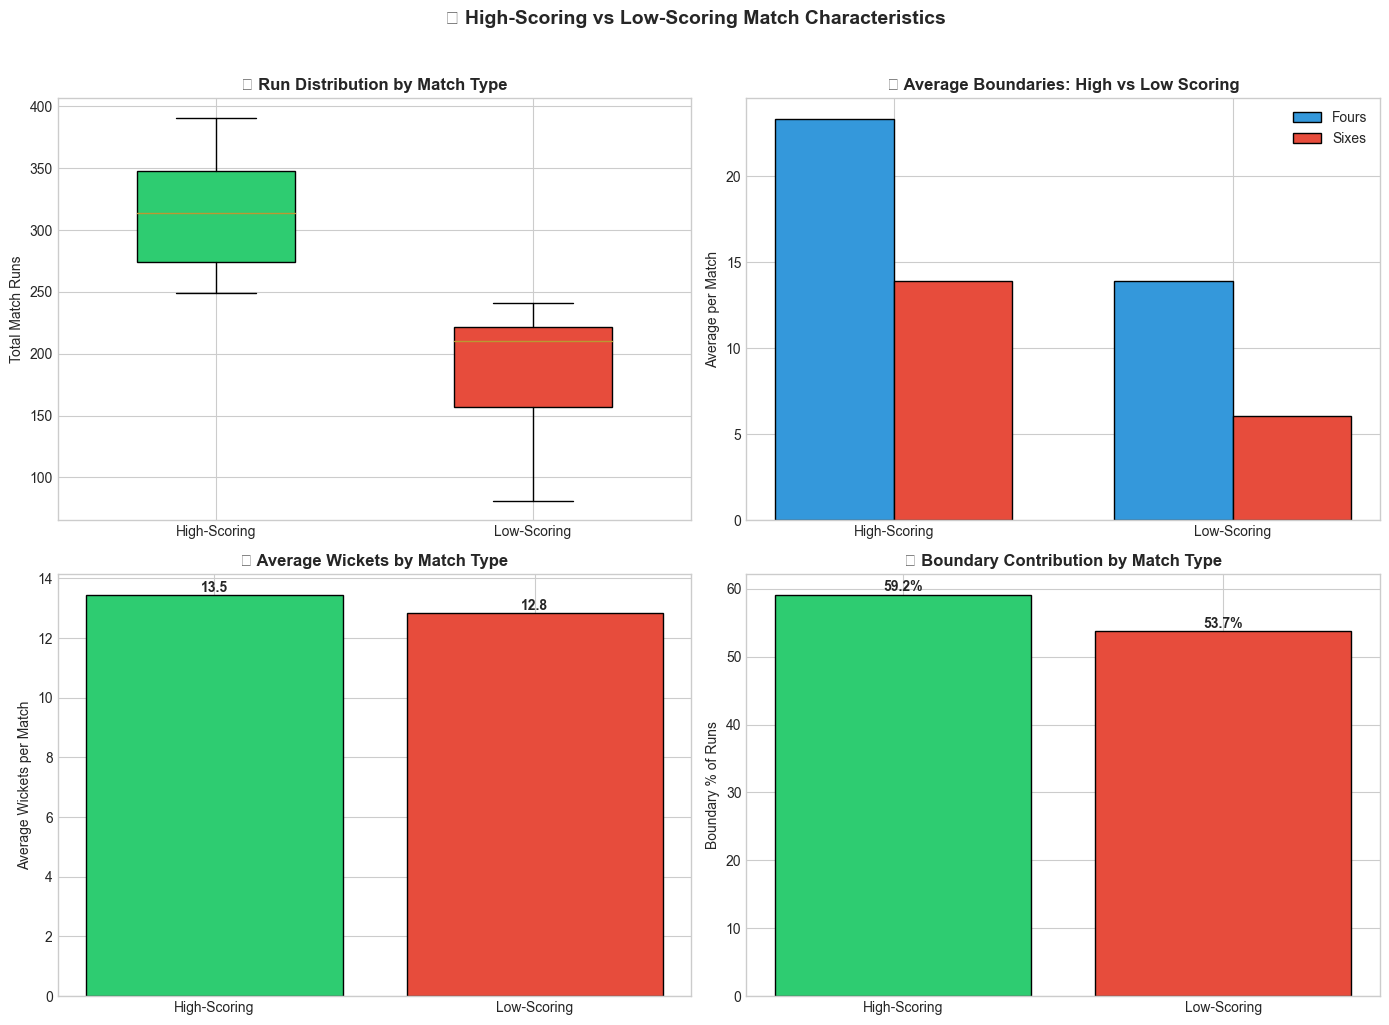


📊 Match Type Summary:
Median total runs: 245.0


,Avg Runs,Avg Fours,Avg Sixes,Avg Wickets,Boundary %
match_type,,,,,
High-Scoring,313.15,23.35,13.88,13.46,59.16
Low-Scoring,189.31,13.88,6.08,12.85,53.74


In [36]:
# Calculate match totals
match_totals = deliveries.groupby('match_id').agg({
    'total_runs': 'sum',
    'runs_off_bat': 'sum',
    'is_four': 'sum',
    'is_six': 'sum',
    'ball': 'count',
    'wicket_type': lambda x: x.notna().sum()
}).reset_index()

match_totals['boundary_runs'] = match_totals['is_four'] * 4 + match_totals['is_six'] * 6
match_totals['boundary_pct'] = (match_totals['boundary_runs'] / match_totals['runs_off_bat'] * 100).round(2)
match_totals['wickets'] = match_totals['wicket_type']

# Classify matches
median_runs = match_totals['total_runs'].median()
match_totals['match_type'] = match_totals['total_runs'].apply(
    lambda x: 'High-Scoring' if x > median_runs else 'Low-Scoring')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Box plot: Total runs distribution
ax1 = axes[0, 0]
colors = ['#2ecc71', '#e74c3c']
match_types = ['High-Scoring', 'Low-Scoring']
for i, mtype in enumerate(match_types):
    data = match_totals[match_totals['match_type'] == mtype]['total_runs']
    bp = ax1.boxplot([data], positions=[i], widths=0.5, patch_artist=True)
    bp['boxes'][0].set_facecolor(colors[i])
ax1.set_xticks([0, 1])
ax1.set_xticklabels(match_types)
ax1.set_ylabel('Total Match Runs')
ax1.set_title('📊 Run Distribution by Match Type', fontsize=12, fontweight='bold')

# Grouped bar: Avg boundaries per match
ax2 = axes[0, 1]
boundary_stats = match_totals.groupby('match_type')[['is_four', 'is_six']].mean()
x = np.arange(len(boundary_stats))
width = 0.35
bars1 = ax2.bar(x - width/2, boundary_stats['is_four'], width, label='Fours', color='#3498db', edgecolor='black')
bars2 = ax2.bar(x + width/2, boundary_stats['is_six'], width, label='Sixes', color='#e74c3c', edgecolor='black')
ax2.set_xticks(x)
ax2.set_xticklabels(boundary_stats.index)
ax2.set_ylabel('Average per Match')
ax2.set_title('📊 Average Boundaries: High vs Low Scoring', fontsize=12, fontweight='bold')
ax2.legend()

# Average wickets comparison
ax3 = axes[1, 0]
wicket_stats = match_totals.groupby('match_type')['wickets'].mean()
colors_wkt = ['#2ecc71' if idx == 'High-Scoring' else '#e74c3c' for idx in wicket_stats.index]
ax3.bar(wicket_stats.index, wicket_stats.values, color=colors_wkt, edgecolor='black')
ax3.set_ylabel('Average Wickets per Match')
ax3.set_title('📊 Average Wickets by Match Type', fontsize=12, fontweight='bold')
for i, v in enumerate(wicket_stats.values):
    ax3.text(i, v + 0.1, f'{v:.1f}', ha='center', fontweight='bold')

# Boundary percentage comparison
ax4 = axes[1, 1]
bnd_pct_stats = match_totals.groupby('match_type')['boundary_pct'].mean()
colors_bnd = ['#2ecc71' if idx == 'High-Scoring' else '#e74c3c' for idx in bnd_pct_stats.index]
ax4.bar(bnd_pct_stats.index, bnd_pct_stats.values, color=colors_bnd, edgecolor='black')
ax4.set_ylabel('Boundary % of Runs')
ax4.set_title('📊 Boundary Contribution by Match Type', fontsize=12, fontweight='bold')
for i, v in enumerate(bnd_pct_stats.values):
    ax4.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.suptitle('🔥 High-Scoring vs Low-Scoring Match Characteristics', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n📊 Match Type Summary:")
print(f"Median total runs: {median_runs}")
summary = match_totals.groupby('match_type').agg({
    'total_runs': 'mean',
    'is_four': 'mean',
    'is_six': 'mean',
    'wickets': 'mean',
    'boundary_pct': 'mean'
}).round(2)
summary.columns = ['Avg Runs', 'Avg Fours', 'Avg Sixes', 'Avg Wickets', 'Boundary %']
display(summary)

---

## 📊 Summary & Key Insights

### 🏏 Batting Insights
- **Top Scorers**: Identified the leading run-scorers with their strike rates and averages
- **Consistency**: Players with low standard deviation showed more reliable performances
- **Boundary Dependence**: High strike rates typically correlated with high boundary percentages
- **Match Context**: Batting in wins vs losses showed distinct patterns in aggression and consistency
- **Team Strength**: Some teams relied heavily on top-order while others had balanced contributions

### 🎯 Bowling Insights
- **Wicket-Takers**: Top performers identified with their economy rates and strike rates
- **Economy vs Strike Rate**: Quality bowlers balanced both metrics effectively
- **Dot Ball Effectiveness**: High dot ball percentage strongly correlated with low economy
- **Phase Analysis**: Powerplay and death overs showed different wicket-taking patterns
- **Team Performance**: Consistent bowling units correlated with tournament success

### ⚖️ Combined Insights
- **Team Balance**: Teams with strong both batting and bowling performed better overall
- **Venue Impact**: Different venues favored batting or bowling distinctly
- **Match Patterns**: High-scoring matches showed different characteristics than low-scoring ones
- **Win Correlation**: Balanced teams with good bowling economy and batting strike rates won more

---

*This comprehensive EDA provides actionable insights for cricket analysts, fantasy league participants, and team strategists for ICC T20 World Cup 2024.*